# Stage 1 Final Notebook: EMG-IMU ASL Letter Classification

This notebook finalises Stage 1 for thesis submission using five models:

- CNN1D
- LSTM
- BiLSTM
- CNN-BiLSTM
- CNN-BiLSTM without dropout

It performs:

1. Dataset loading and analysis
2. Original dataset baseline without augmentation
3. Paper-backed LIS-style angular augmentation
4. Model comparison before and after augmentation
5. Training, validation, and test curves for every model
6. Final CNN-BiLSTM without dropout saving for Stage 2
7. Chapter 4 outputs: tables, curves, confusion matrix, classification report


In [1]:
# ============================================================
# 1. Imports and environment setup
# ============================================================

import os
import re
import json
import math
import time
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LSTM,
    Bidirectional,
    Conv1D,
    MaxPooling1D,
    GlobalAveragePooling1D,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import optimizers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

# Main constants
TARGET_LEN = 100
N_FEATURES = 14
N_CLASSES = 26

LETTERS = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
label_map = {letter: idx for idx, letter in enumerate(LETTERS)}
inv_label_map = {idx: letter for letter, idx in label_map.items()}

# Output folder
if Path("/kaggle/working").exists():
    BASE_DIR = Path("/kaggle/working/Dataset")
else:
    BASE_DIR = Path("./Dataset")

BASE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = BASE_DIR / "stage1_final_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_DIR = OUTPUT_DIR / "dataset_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

NOAUG_DIR = OUTPUT_DIR / "no_augmentation_results"
NOAUG_DIR.mkdir(parents=True, exist_ok=True)

AUG_DIR = OUTPUT_DIR / "augmented_within_dataset_results"
AUG_DIR.mkdir(parents=True, exist_ok=True)

FINAL_DIR = OUTPUT_DIR / "final_cnn_bilstm"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# Stage 2 expected output names
MODEL_PATH = BASE_DIR / "stage1_augmented_split1_model.keras"
MEAN_PATH = BASE_DIR / "stage1_augmented_split1_mean.npy"
STD_PATH = BASE_DIR / "stage1_augmented_split1_std.npy"
LABEL_MAP_PATH = BASE_DIR / "stage1_label_map.json"

with open(LABEL_MAP_PATH, "w") as f:
    json.dump(label_map, f, indent=2)

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("MODEL_PATH:", MODEL_PATH)

2026-06-15 11:01:07.461602: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781521267.676575      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781521267.735890      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781521268.228852      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781521268.228902      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781521268.228904      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
BASE_DIR: /kaggle/working/Dataset
OUTPUT_DIR: /kaggle/working/Dataset/stage1_final_outputs
MODEL_PATH: /kaggle/working/Dataset/stage1_augmented_split1_model.keras


In [2]:
# ============================================================
# 2. Dataset path detection
# ============================================================


def find_dataset_root():
    """
    Finds Dataset_1_Converted in Kaggle, Colab, or local environment.
    It supports both extracted folders and uploaded zip files.
    """
    possible_roots = []

    # Kaggle common locations
    if Path("/kaggle/input").exists():
        possible_roots.extend(Path("/kaggle/input").rglob("Dataset_1_Converted"))
        possible_roots.extend(Path("/kaggle/input").rglob("Dataset_1_Converted.zip"))

    # Local/common locations
    possible_roots.extend(Path(".").rglob("Dataset_1_Converted"))
    possible_roots.extend(Path(".").rglob("Dataset_1_Converted.zip"))
    possible_roots.extend(Path("/mnt/data").rglob("Dataset_1_Converted")) if Path("/mnt/data").exists() else []
    possible_roots.extend(Path("/mnt/data").rglob("Dataset_1_Converted.zip")) if Path("/mnt/data").exists() else []

    # Prefer extracted directory
    for p in possible_roots:
        if p.is_dir() and p.name == "Dataset_1_Converted":
            return p

    # If zip is found, extract it to BASE_DIR
    for p in possible_roots:
        if p.is_file() and p.name == "Dataset_1_Converted.zip":
            extract_dir = BASE_DIR / "Dataset_1_Converted"
            if not extract_dir.exists():
                print("Extracting dataset zip:", p)
                with zipfile.ZipFile(p, "r") as zf:
                    zf.extractall(BASE_DIR)
            return extract_dir

    raise FileNotFoundError(
        "Could not find Dataset_1_Converted or Dataset_1_Converted.zip. "
        "On Kaggle, attach the dataset using Add Data."
    )

ROOT = find_dataset_root()
print("Dataset root:", ROOT)
print("User folders:", sorted([p.name for p in ROOT.iterdir() if p.is_dir()])[:20])

Dataset root: /kaggle/input/datasets/sujitks/dataset-1-final/Dataset_1_Converted
User folders: ['User1', 'User2', 'User3', 'User4', 'User5', 'User6', 'User7', 'User8', 'User9']


In [3]:
# ============================================================
# 3. Helper functions: label parsing, resampling, feature extraction
# ============================================================


def parse_label(filename):
    """
    Extracts ASL letter label from filenames such as:
    alphabet_a_right.json, alphabet_z_right.json, etc.
    Returns uppercase label A-Z or None.
    """
    name = Path(filename).name.lower()

    # Most expected pattern
    m = re.search(r"alphabet[_\- ]*([a-z])[_\- ]*right", name)
    if m:
        return m.group(1).upper()

    # Backup pattern
    m = re.search(r"alphabet[_\- ]*([a-z])", name)
    if m:
        return m.group(1).upper()

    # Backup: single letter file stem
    stem = Path(filename).stem.upper()
    if stem in label_map:
        return stem

    return None


def resample_sequence(seq, target_len=100):
    """
    Resamples a time-series matrix from original length T to target_len.
    Input shape:  T x C
    Output shape: target_len x C
    """
    seq = np.asarray(seq, dtype=np.float32)

    if seq.ndim != 2:
        raise ValueError(f"Expected 2D sequence, got shape {seq.shape}")

    original_len = seq.shape[0]

    if original_len == target_len:
        return seq.astype(np.float32)

    if original_len < 2:
        return np.repeat(seq, target_len, axis=0).astype(np.float32)

    old_idx = np.linspace(0, 1, original_len)
    new_idx = np.linspace(0, 1, target_len)

    out = np.zeros((target_len, seq.shape[1]), dtype=np.float32)

    for c in range(seq.shape[1]):
        out[:, c] = np.interp(new_idx, old_idx, seq[:, c])

    return out.astype(np.float32)


def create_sample_from_json(sample, target_len=TARGET_LEN, use_orientation=False):
    """
    Creates model input from one JSON sample.

    Final thesis input uses 14 features:
    8 EMG + 3 gyroscope + 3 acceleration.

    Orientation is available in the dataset but excluded in the final model.
    """
    emg_data = sample["emg"]["data"]
    imu_data = sample["imu"]["data"]

    T = min(len(emg_data), len(imu_data))
    rows = []

    for i in range(T):
        emg = np.asarray(emg_data[i], dtype=np.float32)
        gyr = np.asarray(imu_data[i]["gyroscope"], dtype=np.float32)
        acc = np.asarray(imu_data[i]["acceleration"], dtype=np.float32)

        if use_orientation:
            ori = np.asarray(imu_data[i]["orientation"], dtype=np.float32)
            row = np.concatenate([emg, gyr, acc, ori], axis=0)
        else:
            row = np.concatenate([emg, gyr, acc], axis=0)

        rows.append(row)

    x = np.asarray(rows, dtype=np.float32)
    x = resample_sequence(x, target_len=target_len)

    return x.astype(np.float32)


def load_original_dataset_from_user_folders(root):
    """
    Loads original converted dataset from User folders.
    Returns X, y, file paths, and metadata.
    """
    x_samples = []
    y_samples = []
    file_paths = []
    metadata_rows = []

    for user_dir in sorted(Path(root).iterdir()):
        if not user_dir.is_dir():
            continue

        user_name = user_dir.name

        for fp in sorted(user_dir.glob("*.json")):
            label = parse_label(fp.name)

            if label is None or label not in label_map:
                continue

            with open(fp, "r") as f:
                sample = json.load(f)

            x = create_sample_from_json(sample, target_len=TARGET_LEN, use_orientation=False)

            emg_len = len(sample["emg"]["data"])
            imu_len = len(sample["imu"]["data"])
            duration = sample.get("duration", None)
            emg_freq = sample.get("emg", {}).get("frequency", None)
            imu_freq = sample.get("imu", {}).get("frequency", None)

            x_samples.append(x)
            y_samples.append(label_map[label])
            file_paths.append(str(fp))

            metadata_rows.append({
                "user": user_name,
                "file": fp.name,
                "label": label,
                "emg_len": emg_len,
                "imu_len": imu_len,
                "used_len": min(emg_len, imu_len),
                "duration": duration,
                "emg_frequency": emg_freq,
                "imu_frequency": imu_freq,
                "path": str(fp)
            })

    X = np.asarray(x_samples, dtype=np.float32)
    y = np.asarray(y_samples, dtype=np.int32)
    metadata_df = pd.DataFrame(metadata_rows)

    return X, y, np.asarray(file_paths), metadata_df


X, y, file_paths, metadata_df = load_original_dataset_from_user_folders(ROOT)

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)
print("Total files:", len(file_paths))
print("Unique labels:", sorted(metadata_df["label"].unique()))
print("Unique users:", sorted(metadata_df["user"].unique()))

display(metadata_df.head())

Original X shape: (1188, 100, 14)
Original y shape: (1188,)
Total files: 1188
Unique labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Unique users: ['User1', 'User2', 'User3', 'User4', 'User5', 'User6', 'User7', 'User8', 'User9']


,user,file,label,emg_len,imu_len,used_len,duration,emg_frequency,imu_frequency,path
0,User1,291982754_alphabet_a_right.json,A,51,51,51,5000,200,200,/kaggle/input/datasets/sujitks/dataset-1-final...
1,User1,291982756_alphabet_a_right.json,A,51,51,51,5000,200,200,/kaggle/input/datasets/sujitks/dataset-1-final...
2,User1,291982757_alphabet_a_right.json,A,51,51,51,5000,200,200,/kaggle/input/datasets/sujitks/dataset-1-final...
3,User1,291982758_alphabet_a_right.json,A,51,51,51,5000,200,200,/kaggle/input/datasets/sujitks/dataset-1-final...
4,User1,291982760_alphabet_a_right.json,A,51,51,51,5000,200,200,/kaggle/input/datasets/sujitks/dataset-1-final...


Label counts:


,letter,count
0,A,45
1,B,45
2,C,45
3,D,45
4,E,45
5,F,45
6,G,46
7,H,48
8,I,46
9,J,45


User counts:


,user,count
0,User1,132
1,User2,132
2,User3,132
3,User4,133
4,User5,134
5,User6,131
6,User7,133
7,User8,130
8,User9,131


Sequence length counts:


,sequence_length,count
0,51,1178
1,102,10


Feature summary:


,feature,min,max,mean,std
0,emg_1,-113.484848,123.606064,-0.746401,11.072020
1,emg_2,-121.696968,123.727272,-0.938675,13.478943
2,emg_3,-126.646461,120.666664,-0.912689,15.847486
3,emg_4,-101.626259,89.000000,-0.726640,7.740515
4,emg_5,-85.979797,119.585861,-0.743618,7.697321
5,emg_6,-126.474747,124.757576,-0.787509,15.855400
6,emg_7,-126.373741,122.959595,-0.794827,17.255692
7,emg_8,-128.000000,124.939392,-0.948241,14.648578
8,gyro_x,-85.208336,115.189819,0.314488,5.763444
9,gyro_y,-98.471939,119.346237,-0.684463,8.808138


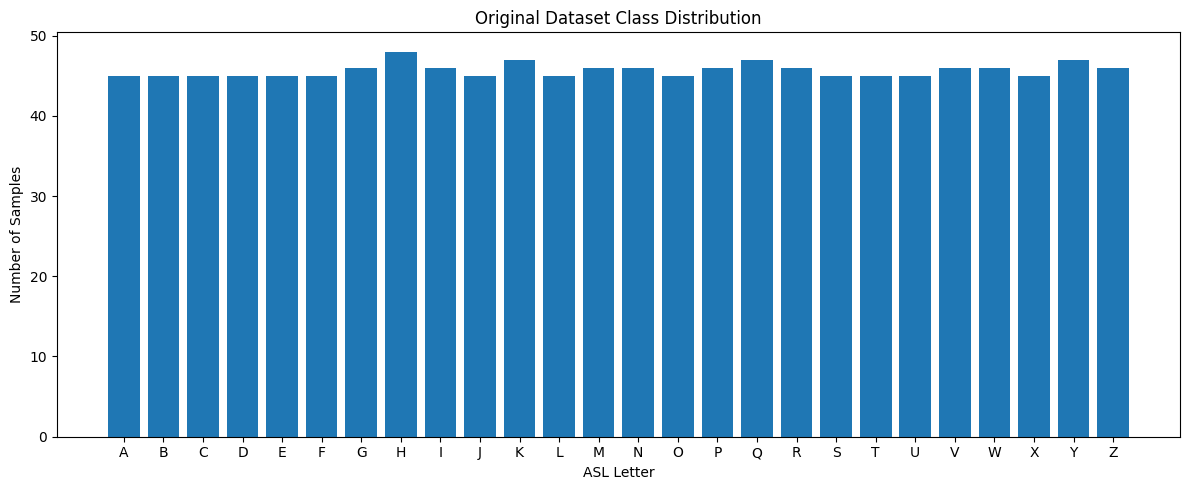

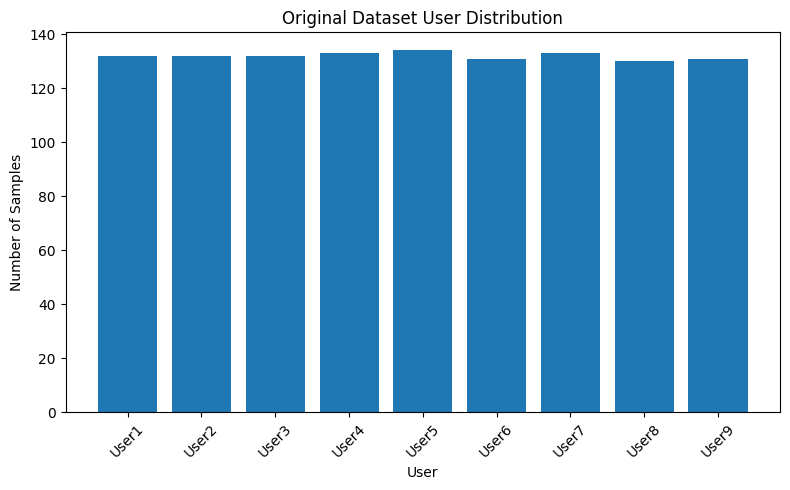

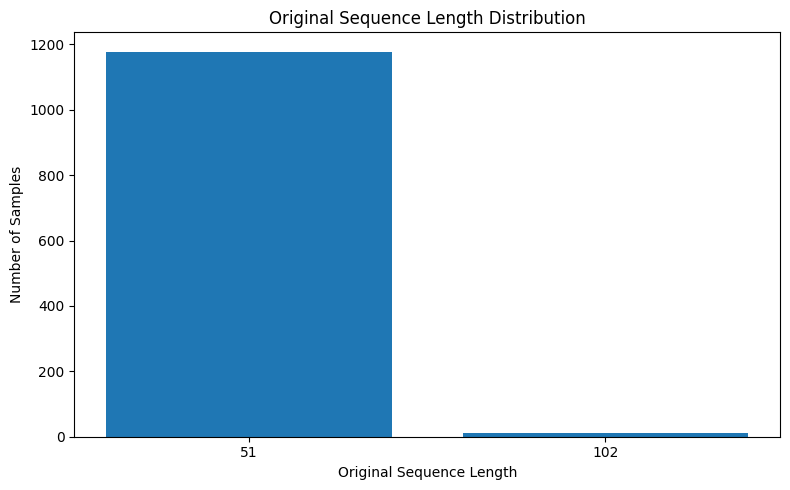

Saved dataset analysis outputs to: /kaggle/working/Dataset/stage1_final_outputs/dataset_analysis


In [4]:
# ============================================================
# 4. Dataset analysis for Chapter 4
# ============================================================

# Save metadata
metadata_path = ANALYSIS_DIR / "dataset_file_metadata.csv"
metadata_df.to_csv(metadata_path, index=False)

# Counts
label_counts = metadata_df["label"].value_counts().sort_index().reset_index()
label_counts.columns = ["letter", "count"]
label_counts_path = ANALYSIS_DIR / "label_counts_original.csv"
label_counts.to_csv(label_counts_path, index=False)

user_counts = metadata_df["user"].value_counts().sort_index().reset_index()
user_counts.columns = ["user", "count"]
user_counts_path = ANALYSIS_DIR / "user_counts_original.csv"
user_counts.to_csv(user_counts_path, index=False)

user_label_counts = pd.crosstab(metadata_df["user"], metadata_df["label"])
user_label_counts_path = ANALYSIS_DIR / "user_label_counts_original.csv"
user_label_counts.to_csv(user_label_counts_path)

seq_len_counts = metadata_df["used_len"].value_counts().sort_index().reset_index()
seq_len_counts.columns = ["sequence_length", "count"]
seq_len_counts_path = ANALYSIS_DIR / "sequence_length_counts.csv"
seq_len_counts.to_csv(seq_len_counts_path, index=False)

# Feature range summary after conversion to 100 x 14
flat_original = X.reshape(-1, X.shape[-1])
feature_names = (
    [f"emg_{i+1}" for i in range(8)] +
    ["gyro_x", "gyro_y", "gyro_z"] +
    ["acc_x", "acc_y", "acc_z"]
)

feature_summary = pd.DataFrame({
    "feature": feature_names,
    "min": flat_original.min(axis=0),
    "max": flat_original.max(axis=0),
    "mean": flat_original.mean(axis=0),
    "std": flat_original.std(axis=0)
})
feature_summary_path = ANALYSIS_DIR / "feature_range_summary_14_features.csv"
feature_summary.to_csv(feature_summary_path, index=False)

print("Label counts:")
display(label_counts)

print("User counts:")
display(user_counts)

print("Sequence length counts:")
display(seq_len_counts)

print("Feature summary:")
display(feature_summary)

# Plots
plt.figure(figsize=(12, 5))
plt.bar(label_counts["letter"], label_counts["count"])
plt.title("Original Dataset Class Distribution")
plt.xlabel("ASL Letter")
plt.ylabel("Number of Samples")
plt.tight_layout()
class_dist_fig = ANALYSIS_DIR / "original_class_distribution.png"
plt.savefig(class_dist_fig, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(user_counts["user"], user_counts["count"])
plt.title("Original Dataset User Distribution")
plt.xlabel("User")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
user_dist_fig = ANALYSIS_DIR / "original_user_distribution.png"
plt.savefig(user_dist_fig, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(seq_len_counts["sequence_length"].astype(str), seq_len_counts["count"])
plt.title("Original Sequence Length Distribution")
plt.xlabel("Original Sequence Length")
plt.ylabel("Number of Samples")
plt.tight_layout()
seq_len_fig = ANALYSIS_DIR / "sequence_length_distribution.png"
plt.savefig(seq_len_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved dataset analysis outputs to:", ANALYSIS_DIR)

In [5]:
# ============================================================
# 5. Paper-backed LIS-style angular augmentation
# ============================================================

ANGLES = [-30, -22.5, -15, -7.5, 7.5, 15, 22.5, 30]


def emg_augmentation(emg_vector, theta):
    """
    Paper-backed LIS-style EMG angular augmentation.

    This applies the same angular idea used in the reference method.
    It is applied to each 8-channel EMG vector.
    """
    emg_vector = np.asarray(emg_vector, dtype=np.float32)

    phi = 45.0
    eta = math.floor(theta / phi)

    denom_factor = phi - eta
    if denom_factor == 0:
        denom_factor = 1e-8

    d = theta / denom_factor

    new_emg = []
    n = len(emg_vector)

    for i in range(n):
        idx1 = (i - eta) % n
        idx2 = (i - eta - 1) % n

        num = (d ** 2) * emg_vector[idx1] + ((1 - d) ** 2) * emg_vector[idx2]
        den = (d ** 2) + ((1 - d) ** 2)

        new_emg.append(num / den if den != 0 else emg_vector[idx1])

    return np.asarray(new_emg, dtype=np.float32)


def imu_augmentation(gyr, acc, theta):
    """
    Paper-backed angular rotation for IMU gyroscope and acceleration.
    Rotation is around the X-axis.
    Orientation is not included in final model input.
    """
    theta_rad = math.radians(theta)

    rot_matrix = np.array([
        [1, 0, 0],
        [0, math.cos(theta_rad), math.sin(theta_rad)],
        [0, -math.sin(theta_rad), math.cos(theta_rad)]
    ], dtype=np.float32)

    gyr = np.asarray(gyr, dtype=np.float32)
    acc = np.asarray(acc, dtype=np.float32)

    new_gyr = np.dot(rot_matrix, gyr)
    new_acc = np.dot(rot_matrix, acc)

    return new_gyr.astype(np.float32), new_acc.astype(np.float32)


def augment_json_sample_lis_style(sample, theta):
    """
    Augments one JSON sample using the paper-backed LIS-style method.
    Returns a new JSON-like sample.
    """
    emg_data = sample["emg"]["data"]
    imu_data = sample["imu"]["data"]

    T = min(len(emg_data), len(imu_data))

    new_emg_data = []
    new_imu_data = []

    for i in range(T):
        emg = emg_data[i]
        gyr = imu_data[i]["gyroscope"]
        acc = imu_data[i]["acceleration"]
        ori = imu_data[i].get("orientation", [0, 0, 0])

        new_emg = emg_augmentation(emg, theta)
        new_gyr, new_acc = imu_augmentation(gyr, acc, theta)

        new_emg_data.append(new_emg.tolist())
        new_imu_data.append({
            "gyroscope": new_gyr.tolist(),
            "acceleration": new_acc.tolist(),
            "orientation": ori
        })

    aug_sample = {
        "timestamp": sample.get("timestamp", None),
        "duration": sample.get("duration", None),
        "emg": {
            "frequency": sample.get("emg", {}).get("frequency", None),
            "data": new_emg_data
        },
        "imu": {
            "frequency": sample.get("imu", {}).get("frequency", None),
            "data": new_imu_data
        }
    }

    return aug_sample


def create_augmented_arrays_before_split(file_paths):
    """
    Creates augmented dataset before random split.

    This is the high-accuracy augmented within-dataset evaluation setup:
    original samples + 8 angular augmented versions per sample.
    """
    X_aug_list = []
    y_aug_list = []
    source_rows = []

    for fp in file_paths:
        fp = Path(fp)
        label = parse_label(fp.name)
        if label is None:
            continue

        with open(fp, "r") as f:
            sample = json.load(f)

        # Original sample
        x_original = create_sample_from_json(sample, target_len=TARGET_LEN, use_orientation=False)
        X_aug_list.append(x_original)
        y_aug_list.append(label_map[label])
        source_rows.append({
            "source_file": str(fp),
            "label": label,
            "augmentation": "original",
            "angle": 0
        })

        # Augmented samples
        for angle in ANGLES:
            aug_sample = augment_json_sample_lis_style(sample, angle)
            x_aug = create_sample_from_json(aug_sample, target_len=TARGET_LEN, use_orientation=False)
            X_aug_list.append(x_aug)
            y_aug_list.append(label_map[label])
            source_rows.append({
                "source_file": str(fp),
                "label": label,
                "augmentation": "LIS_style_angular",
                "angle": angle
            })

    X_aug = np.asarray(X_aug_list, dtype=np.float32)
    y_aug = np.asarray(y_aug_list, dtype=np.int32)
    aug_metadata_df = pd.DataFrame(source_rows)

    return X_aug, y_aug, aug_metadata_df


X_aug, y_aug, aug_metadata_df = create_augmented_arrays_before_split(file_paths)

print("Original X:", X.shape)
print("Augmented X:", X_aug.shape)
print("Augmented y:", y_aug.shape)
print("Augmentation factor:", X_aug.shape[0] / X.shape[0])

display(aug_metadata_df.head())

Original X: (1188, 100, 14)
Augmented X: (10692, 100, 14)
Augmented y: (10692,)
Augmentation factor: 9.0


,source_file,label,augmentation,angle
0,/kaggle/input/datasets/sujitks/dataset-1-final...,A,original,0.0
1,/kaggle/input/datasets/sujitks/dataset-1-final...,A,LIS_style_angular,-30.0
2,/kaggle/input/datasets/sujitks/dataset-1-final...,A,LIS_style_angular,-22.5
3,/kaggle/input/datasets/sujitks/dataset-1-final...,A,LIS_style_angular,-15.0
4,/kaggle/input/datasets/sujitks/dataset-1-final...,A,LIS_style_angular,-7.5


,letter,count_before_augmentation,count_after_augmentation,augmentation_factor
0,A,45,405,9.0
1,B,45,405,9.0
2,C,45,405,9.0
3,D,45,405,9.0
4,E,45,405,9.0
5,F,45,405,9.0
6,G,46,414,9.0
7,H,48,432,9.0
8,I,46,414,9.0
9,J,45,405,9.0


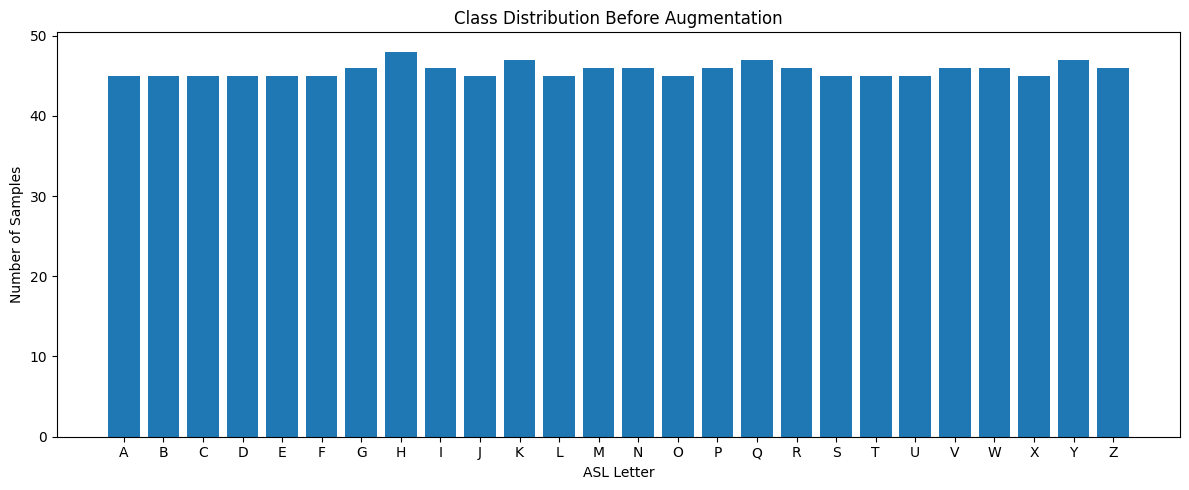

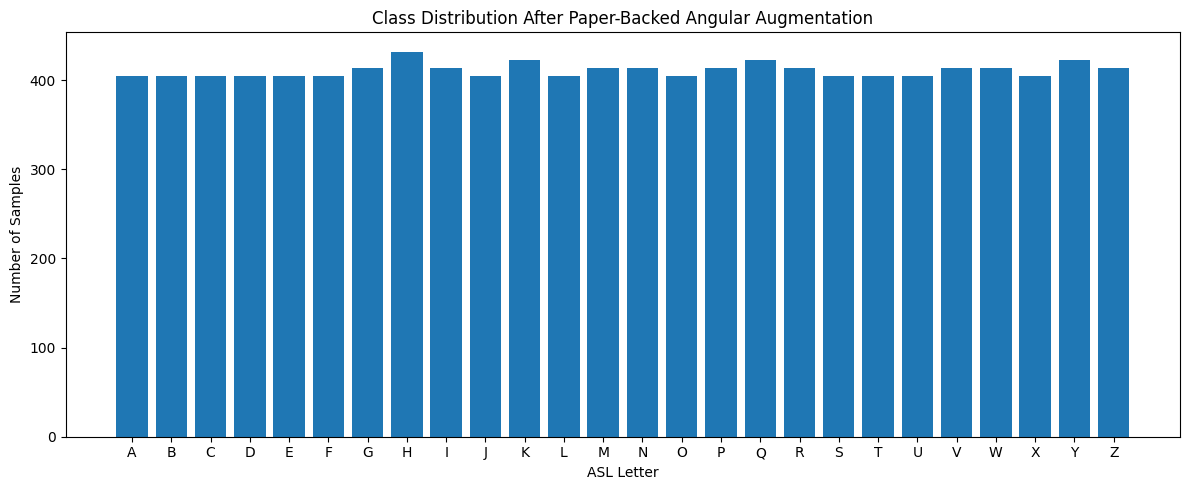

Saved augmentation analysis outputs to: /kaggle/working/Dataset/stage1_final_outputs/dataset_analysis


In [6]:
# ============================================================
# 6. Augmentation analysis for Chapter 4
# ============================================================

aug_metadata_path = ANALYSIS_DIR / "augmentation_metadata_before_split.csv"
aug_metadata_df.to_csv(aug_metadata_path, index=False)

aug_label_counts = aug_metadata_df["label"].value_counts().sort_index().reset_index()
aug_label_counts.columns = ["letter", "count_after_augmentation"]

aug_summary_df = label_counts.merge(aug_label_counts, on="letter", how="left")
aug_summary_df = aug_summary_df.rename(columns={"count": "count_before_augmentation"})
aug_summary_df["augmentation_factor"] = (
    aug_summary_df["count_after_augmentation"] / aug_summary_df["count_before_augmentation"]
)

aug_summary_path = ANALYSIS_DIR / "class_distribution_before_after_augmentation.csv"
aug_summary_df.to_csv(aug_summary_path, index=False)

display(aug_summary_df)

plt.figure(figsize=(12, 5))
plt.bar(aug_summary_df["letter"], aug_summary_df["count_before_augmentation"])
plt.title("Class Distribution Before Augmentation")
plt.xlabel("ASL Letter")
plt.ylabel("Number of Samples")
plt.tight_layout()
before_fig = ANALYSIS_DIR / "class_distribution_before_augmentation.png"
plt.savefig(before_fig, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(aug_summary_df["letter"], aug_summary_df["count_after_augmentation"])
plt.title("Class Distribution After Paper-Backed Angular Augmentation")
plt.xlabel("ASL Letter")
plt.ylabel("Number of Samples")
plt.tight_layout()
after_fig = ANALYSIS_DIR / "class_distribution_after_augmentation.png"
plt.savefig(after_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved augmentation analysis outputs to:", ANALYSIS_DIR)

In [7]:
# ============================================================
# 7. Split and normalisation utilities
# ============================================================


def make_stratified_split(X_data, y_data, test_size=0.2, seed=SEED):
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=seed
    )

    train_idx, test_idx = next(splitter.split(X_data, y_data))

    X_train_raw = X_data[train_idx]
    y_train = y_data[train_idx]
    X_test_raw = X_data[test_idx]
    y_test = y_data[test_idx]

    return X_train_raw, X_test_raw, y_train, y_test, train_idx, test_idx


def standardise_train_test(X_train_raw, X_test_raw):
    """
    Calculates mean/std from training only and applies to train and test.
    """
    flat = X_train_raw.reshape(-1, X_train_raw.shape[-1])

    mean = flat.mean(axis=0, keepdims=True)
    std = flat.std(axis=0, keepdims=True) + 1e-8

    X_train = ((X_train_raw - mean) / std).astype(np.float32)
    X_test = ((X_test_raw - mean) / std).astype(np.float32)

    return X_train, X_test, mean.astype(np.float32), std.astype(np.float32)


# Original no-augmentation split
X_train_noaug_raw, X_test_noaug_raw, y_train_noaug, y_test_noaug, train_idx_noaug, test_idx_noaug = make_stratified_split(
    X, y, test_size=0.2, seed=SEED
)

X_train_noaug, X_test_noaug, mean_noaug, std_noaug = standardise_train_test(
    X_train_noaug_raw, X_test_noaug_raw
)

y_train_noaug_cat = to_categorical(y_train_noaug, num_classes=N_CLASSES)
y_test_noaug_cat = to_categorical(y_test_noaug, num_classes=N_CLASSES)

print("No-augmentation split")
print("X_train_noaug:", X_train_noaug.shape)
print("X_test_noaug :", X_test_noaug.shape)

# Augmented before-split setup
X_train_aug_raw, X_test_aug_raw, y_train_aug, y_test_aug, train_idx_aug, test_idx_aug = make_stratified_split(
    X_aug, y_aug, test_size=0.2, seed=SEED
)

X_train_aug, X_test_aug, mean_aug, std_aug = standardise_train_test(
    X_train_aug_raw, X_test_aug_raw
)

y_train_aug_cat = to_categorical(y_train_aug, num_classes=N_CLASSES)
y_test_aug_cat = to_categorical(y_test_aug, num_classes=N_CLASSES)

print("Augmented within-dataset split")
print("X_train_aug:", X_train_aug.shape)
print("X_test_aug :", X_test_aug.shape)

# Save split summaries
split_summary_df = pd.DataFrame([
    {
        "setup": "No augmentation",
        "train_samples": X_train_noaug.shape[0],
        "test_samples": X_test_noaug.shape[0],
        "input_shape": f"{TARGET_LEN} x {N_FEATURES}"
    },
    {
        "setup": "Paper-backed augmentation before split",
        "train_samples": X_train_aug.shape[0],
        "test_samples": X_test_aug.shape[0],
        "input_shape": f"{TARGET_LEN} x {N_FEATURES}"
    }
])

split_summary_path = ANALYSIS_DIR / "stage1_split_summary.csv"
split_summary_df.to_csv(split_summary_path, index=False)
display(split_summary_df)

No-augmentation split
X_train_noaug: (950, 100, 14)
X_test_noaug : (238, 100, 14)
Augmented within-dataset split
X_train_aug: (8553, 100, 14)
X_test_aug : (2139, 100, 14)


,setup,train_samples,test_samples,input_shape
0,No augmentation,950,238,100 x 14
1,Paper-backed augmentation before split,8553,2139,100 x 14


In [8]:
# ============================================================
# 8. Model builders: CNN1D, LSTM, BiLSTM, CNN-BiLSTM,
#    and CNN-BiLSTM without dropout
# ============================================================

INPUT_SHAPE = (TARGET_LEN, N_FEATURES)


def compile_model(model, learning_rate=0.001):
    optimizer = optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def build_cnn1d_model():
    model = Sequential([
        Input(shape=INPUT_SHAPE),

        Conv1D(64, kernel_size=5, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(128, kernel_size=3, padding="same", activation="relu"),
        BatchNormalization(),

        GlobalAveragePooling1D(),

        Dense(64, activation="relu"),
        Dropout(0.5),

        Dense(N_CLASSES, activation="softmax")
    ], name="CNN1D")

    return compile_model(model)


def build_lstm_model():
    model = Sequential([
        Input(shape=INPUT_SHAPE),

        LSTM(64, return_sequences=True),
        LSTM(32),

        Dropout(0.5),

        Dense(64, activation="relu"),
        Dropout(0.5),

        Dense(N_CLASSES, activation="softmax")
    ], name="LSTM")

    return compile_model(model)


def build_bilstm_model():
    model = Sequential([
        Input(shape=INPUT_SHAPE),

        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),

        Dropout(0.5),

        Dense(64, activation="relu"),
        Dropout(0.5),

        Dense(N_CLASSES, activation="softmax")
    ], name="BiLSTM")

    return compile_model(model)


def build_cnn_bilstm_model():
    model = Sequential([
        Input(shape=INPUT_SHAPE),

        Conv1D(64, kernel_size=3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Bidirectional(LSTM(64)),

        Dropout(0.5),

        Dense(64, activation="relu"),
        Dropout(0.5),

        Dense(N_CLASSES, activation="softmax")
    ], name="CNN_BiLSTM")

    return compile_model(model)


def build_cnn_bilstm_no_dropout_model():
    """
    Same CNN-BiLSTM architecture as above, with only the Dropout
    layers removed.
    """
    model = Sequential([
        Input(shape=INPUT_SHAPE),

        Conv1D(64, kernel_size=3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Bidirectional(LSTM(64)),

        Dense(64, activation="relu"),

        Dense(N_CLASSES, activation="softmax")
    ], name="CNN_BiLSTM_NoDropout")

    return compile_model(model)


MODEL_BUILDERS = {
    "CNN1D": build_cnn1d_model,
    "LSTM": build_lstm_model,
    "BiLSTM": build_bilstm_model,
    "CNN_BiLSTM": build_cnn_bilstm_model,
    "CNN_BiLSTM_NoDropout": build_cnn_bilstm_no_dropout_model
}

print("Models included:", list(MODEL_BUILDERS.keys()))


Models included: ['CNN1D', 'LSTM', 'BiLSTM', 'CNN_BiLSTM', 'CNN_BiLSTM_NoDropout']


In [9]:
# ============================================================
# 9. Training and evaluation function
# ============================================================


class TestMetricsCallback(Callback):
    """
    Evaluates the test set at the end of every epoch so that test
    accuracy and test loss can be displayed as curves.

    These test values are recorded only for plotting. They are not
    used by EarlyStopping or ModelCheckpoint.
    """

    def __init__(self, X_test, y_test_cat):
        super().__init__()
        self.X_test = X_test
        self.y_test_cat = y_test_cat
        self.test_accuracy = []
        self.test_loss = []

    def on_epoch_end(self, epoch, logs=None):
        test_loss, test_accuracy = self.model.evaluate(
            self.X_test,
            self.y_test_cat,
            verbose=0
        )

        self.test_loss.append(float(test_loss))
        self.test_accuracy.append(float(test_accuracy))

        if logs is not None:
            logs["test_loss"] = float(test_loss)
            logs["test_accuracy"] = float(test_accuracy)

        print(
            f" - test_loss: {test_loss:.4f}"
            f" - test_accuracy: {test_accuracy:.4f}"
        )


def train_and_compare_models(
    setup_name,
    X_train,
    y_train,
    y_train_cat,
    X_test,
    y_test,
    y_test_cat,
    output_dir,
    epochs=100,
    batch_size=64,
    patience=8
):
    """
    Trains all models for one experimental setup.
    Saves model files, metrics, classification reports,
    confusion matrices, and training/validation/test histories.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    results = []
    trained_models = {}
    histories = {}
    predictions = {}

    for model_name, builder in MODEL_BUILDERS.items():
        print("\n" + "=" * 80)
        print(f"Setup: {setup_name}")
        print(f"Training model: {model_name}")
        print("=" * 80)

        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)
        np.random.seed(SEED)
        random.seed(SEED)

        model = builder()
        model.summary()

        model_path = output_dir / f"{model_name}_best.keras"

        test_metrics_callback = TestMetricsCallback(
            X_test=X_test,
            y_test_cat=y_test_cat
        )

        callbacks = [
            test_metrics_callback,
            EarlyStopping(
                monitor="val_loss",
                patience=patience,
                restore_best_weights=True
            ),
            ModelCheckpoint(
                filepath=str(model_path),
                monitor="val_loss",
                save_best_only=True
            )
        ]

        start_time = time.time()

        history = model.fit(
            X_train,
            y_train_cat,
            validation_split=0.125,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )

        training_time = time.time() - start_time

        # Add epoch-by-epoch test values to the same history object.
        history.history["test_accuracy"] = (
            test_metrics_callback.test_accuracy
        )
        history.history["test_loss"] = (
            test_metrics_callback.test_loss
        )

        test_loss, test_acc = model.evaluate(
            X_test,
            y_test_cat,
            verbose=0
        )

        y_prob = model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

        acc = accuracy_score(y_test, y_pred)
        macro_precision = precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        )
        macro_recall = recall_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        )
        macro_f1 = f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        )
        weighted_f1 = f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        best_val_acc = max(history.history["val_accuracy"])
        best_val_loss = min(history.history["val_loss"])

        results.append({
            "setup": setup_name,
            "model": model_name,
            "test_loss": float(test_loss),
            "test_accuracy": float(acc),
            "macro_precision": float(macro_precision),
            "macro_recall": float(macro_recall),
            "macro_f1": float(macro_f1),
            "weighted_f1": float(weighted_f1),
            "best_val_accuracy": float(best_val_acc),
            "best_val_loss": float(best_val_loss),
            "epochs_trained": len(history.history["loss"]),
            "training_time_seconds": float(training_time),
            "saved_model_path": str(model_path)
        })

        trained_models[model_name] = model
        histories[model_name] = history
        predictions[model_name] = y_pred

        # Save complete training, validation, and test history.
        history_df = pd.DataFrame(history.history)
        history_df.to_csv(
            output_dir / f"{model_name}_training_history.csv",
            index=False
        )

        # Save classification report.
        report_dict = classification_report(
            y_test,
            y_pred,
            labels=list(range(N_CLASSES)),
            target_names=[
                inv_label_map[i]
                for i in range(N_CLASSES)
            ],
            zero_division=0,
            output_dict=True
        )
        report_df = pd.DataFrame(report_dict).transpose()
        report_df.to_csv(
            output_dir / f"{model_name}_classification_report.csv"
        )

        # Save confusion matrix.
        cm = confusion_matrix(
            y_test,
            y_pred,
            labels=list(range(N_CLASSES))
        )
        cm_df = pd.DataFrame(
            cm,
            index=[
                inv_label_map[i]
                for i in range(N_CLASSES)
            ],
            columns=[
                inv_label_map[i]
                for i in range(N_CLASSES)
            ]
        )
        cm_df.to_csv(
            output_dir / f"{model_name}_confusion_matrix.csv"
        )

        epochs_axis = range(len(history.history["accuracy"]))

        # Accuracy graph with training, validation, and test curves.
        plt.figure(figsize=(10, 6))
        plt.plot(
            epochs_axis,
            history.history["accuracy"],
            label="Training Accuracy"
        )
        plt.plot(
            epochs_axis,
            history.history["val_accuracy"],
            label="Validation Accuracy"
        )
        plt.plot(
            epochs_axis,
            history.history["test_accuracy"],
            label="Test Accuracy"
        )
        plt.title(f"{setup_name} - {model_name} Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.tight_layout()
        plt.savefig(
            output_dir / f"{model_name}_accuracy_curve.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

        # Loss graph with training, validation, and test curves.
        plt.figure(figsize=(10, 6))
        plt.plot(
            epochs_axis,
            history.history["loss"],
            label="Training Loss"
        )
        plt.plot(
            epochs_axis,
            history.history["val_loss"],
            label="Validation Loss"
        )
        plt.plot(
            epochs_axis,
            history.history["test_loss"],
            label="Test Loss"
        )
        plt.title(f"{setup_name} - {model_name} Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.tight_layout()
        plt.savefig(
            output_dir / f"{model_name}_loss_curve.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

        print(f"Finished {model_name}")
        print("Test Accuracy:", acc)
        print("Macro F1:", macro_f1)

    results_df = pd.DataFrame(results).sort_values(
        by="test_accuracy",
        ascending=False
    )
    results_df.to_csv(
        output_dir / "model_comparison_results.csv",
        index=False
    )

    print("Final results for setup:", setup_name)
    display(results_df)

    return results_df, trained_models, histories, predictions



Setup: No augmentation
Training model: CNN1D


I0000 00:00:1781521309.459566      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781521309.465830      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CNN1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 64)        │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,962 (156.10 KB)

...

Epoch 1/100


I0000 00:00:1781521312.659728      71 service.cc:152] XLA service 0x7d98f80100b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781521312.659775      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781521312.659782      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781521313.058889      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/13 ━━━━━━━━━━━━━━━━━━━━ 1:03 5s/step - accuracy: 0.0781 - loss: 3.4210

I0000 00:00:1781521316.356838      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.0566 - loss: 3.3534 - test_loss: 3.2285 - test_accuracy: 0.0672
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 455ms/step - accuracy: 0.0710 - loss: 3.2700 - val_accuracy: 0.0420 - val_loss: 3.2191 - test_loss: 3.2285 - test_accuracy: 0.0672
Epoch 2/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1250 - loss: 3.0900 - test_loss: 3.1929 - test_accuracy: 0.0966
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1300 - loss: 3.0603 - val_accuracy: 0.0924 - val_loss: 3.1863 - test_loss: 3.1929 - test_accuracy: 0.0966
Epoch 3/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0938 - loss: 3.1165 - test_loss: 3.1490 - test_accuracy: 0.1303
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1685 - loss: 2.9476 - val_accuracy: 0.1261 - val_loss: 3.1428 - test_loss: 3.1490 - test_accuracy: 0.1303
Epoch 4/100
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2188 - loss: 2.9064 - test_loss: 3.1150 - test_accuracy: 0.1765
13/13 ━━━

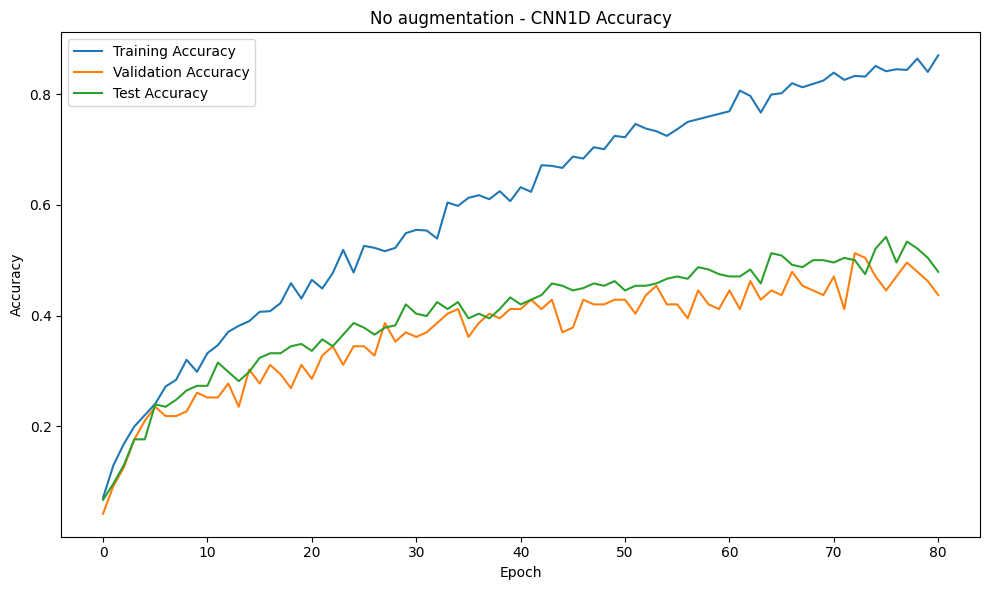

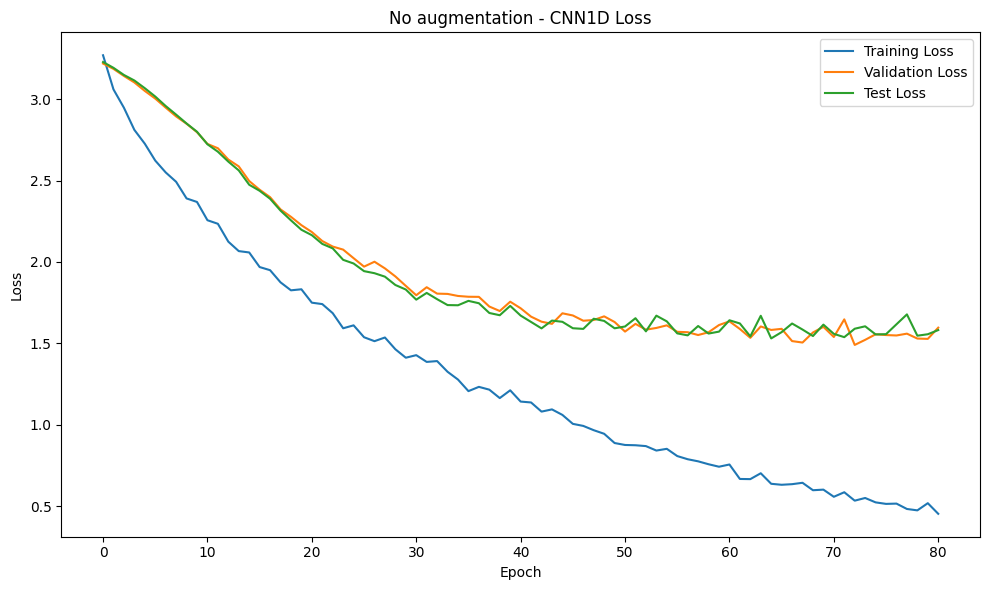

Finished CNN1D
Test Accuracy: 0.5
Macro F1: 0.49958873855181984

Setup: No augmentation
Training model: LSTM


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,442 (142.35 KB)

 Trainable params: 36,442 (142.35 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0391 - loss: 3.2774 - test_loss: 3.2556 - test_accuracy: 0.0378
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.0361 - loss: 3.2692 - val_accuracy: 0.0336 - val_loss: 3.2517 - test_loss: 3.2556 - test_accuracy: 0.0378
Epoch 2/100
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0416 - loss: 3.2530 - test_loss: 3.2510 - test_accuracy: 0.0672
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0457 - loss: 3.2570 - val_accuracy: 0.0420 - val_loss: 3.2486 - test_loss: 3.2510 - test_accuracy: 0.0672
Epoch 3/100
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0462 - loss: 3.2611 - test_loss: 3.2468 - test_accuracy: 0.0588
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0505 - loss: 3.2527 - val_accuracy: 0.0756 - val_loss: 3.2458 - test_loss: 3.2468 - test_accuracy: 0.0588
Epoch 4/100
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0439 - loss: 3.2416 - test_loss: 3.2412 - test_accuracy: 0.0504


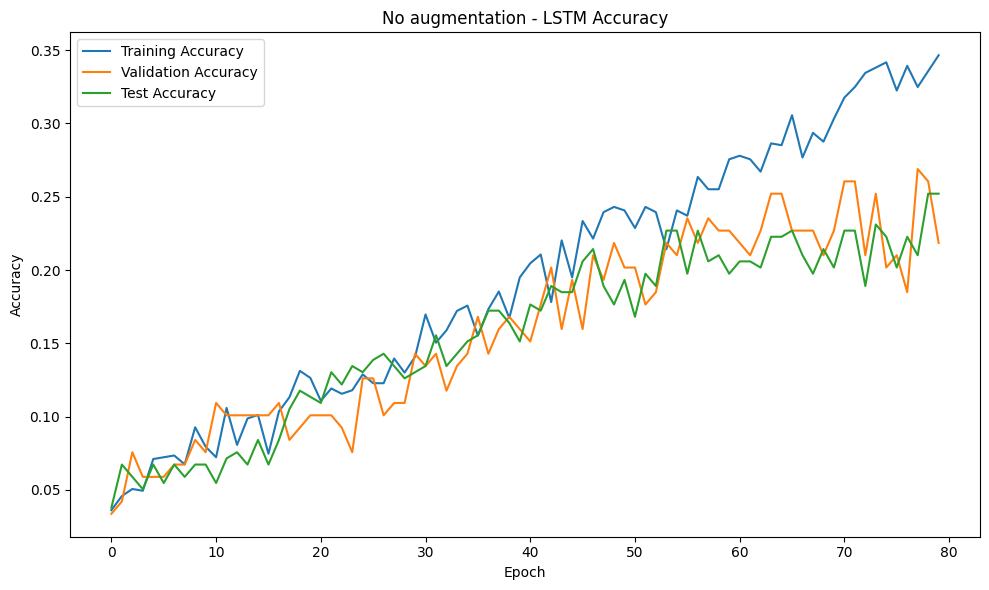

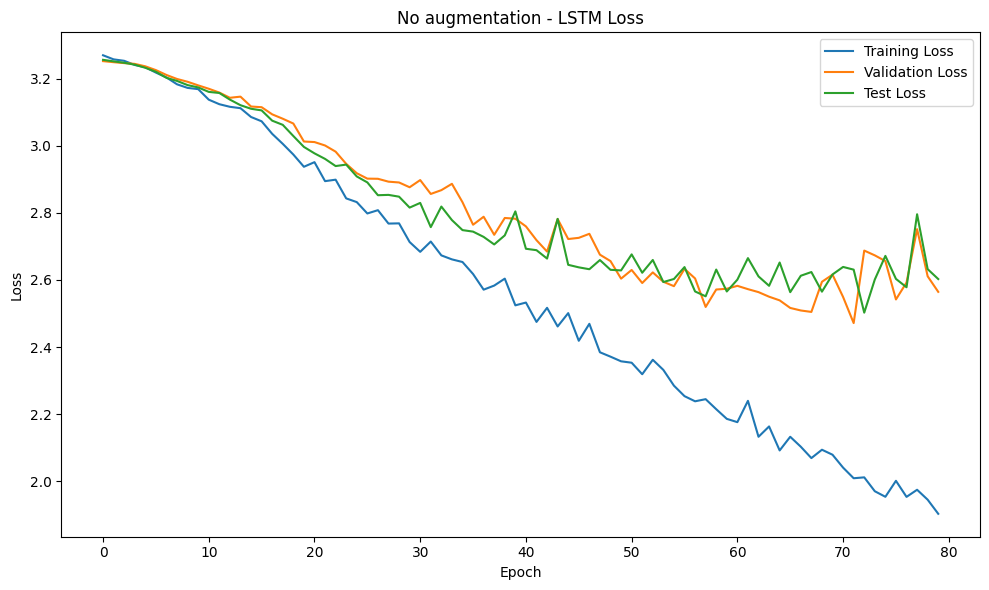

Finished LSTM
Test Accuracy: 0.226890756302521
Macro F1: 0.19509396818595962

Setup: No augmentation
Training model: BiLSTM


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,514 (341.85 KB)

 Trainable params: 87,514 (341.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0401 - loss: 3.2719 - test_loss: 3.2492 - test_accuracy: 0.0672
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.0421 - loss: 3.2734 - val_accuracy: 0.0420 - val_loss: 3.2581 - test_loss: 3.2492 - test_accuracy: 0.0672
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0512 - loss: 3.2661 - test_loss: 3.2428 - test_accuracy: 0.0756
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.0517 - loss: 3.2609 - val_accuracy: 0.0336 - val_loss: 3.2583 - test_loss: 3.2428 - test_accuracy: 0.0756
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0600 - loss: 3.2401 - test_loss: 3.2363 - test_accuracy: 0.0756
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.0505 - loss: 3.2385 - val_accuracy: 0.0252 - val_loss: 3.2443 - test_loss: 3.2363 - test_accuracy: 0.0756
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0783 - loss: 3.2167 - test_loss: 3.2217 - test_accuracy: 0.0924


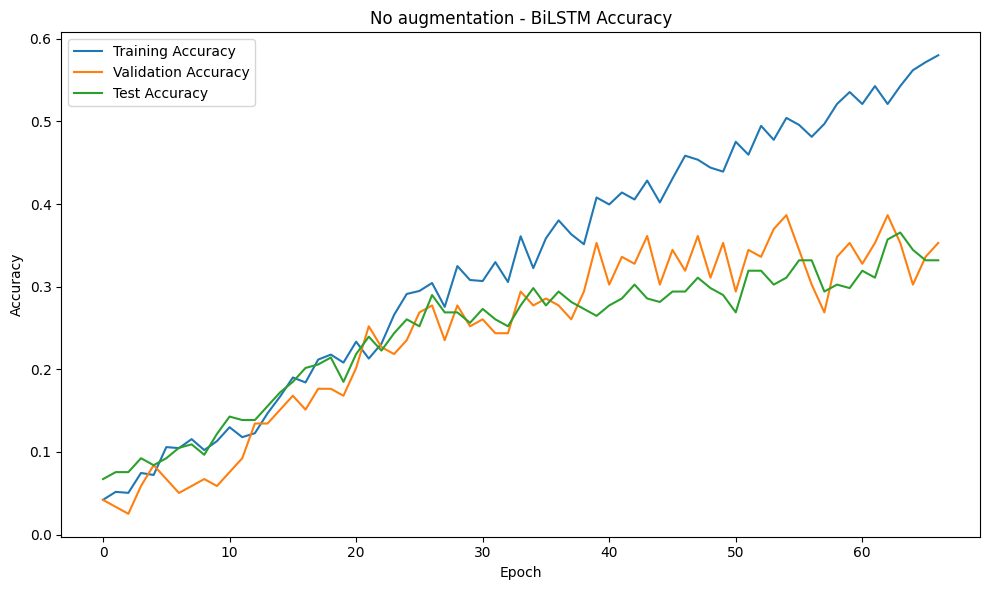

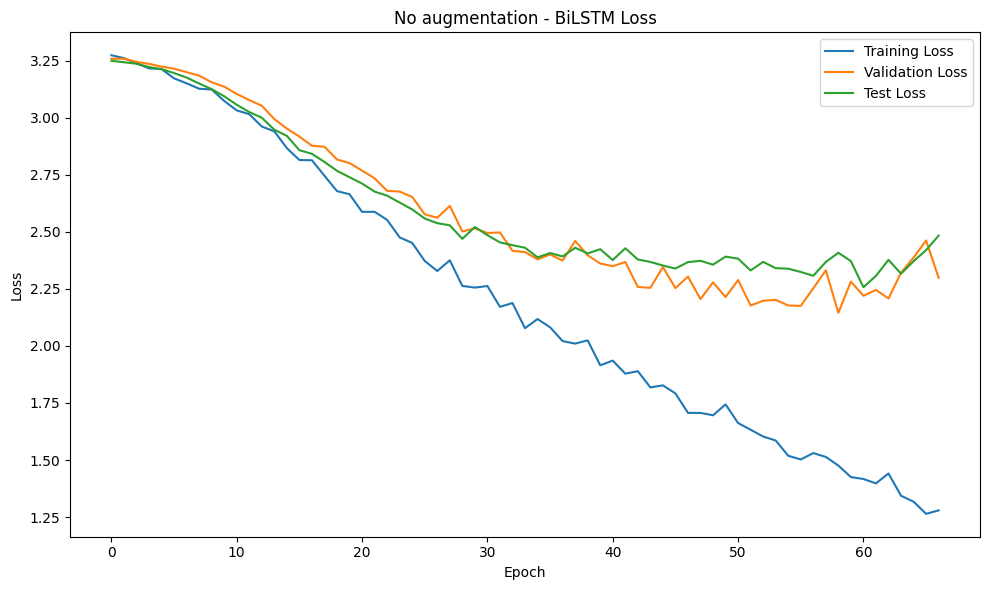

Finished BiLSTM
Test Accuracy: 0.3025210084033613
Macro F1: 0.28692445934436783

Setup: No augmentation
Training model: CNN_BiLSTM


Model: "CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 64)        │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,002 (308.60 KB)

 Trainable params: 78,874 (308.10 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0405 - loss: 3.3397 - test_loss: 3.2475 - test_accuracy: 0.0462
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.0337 - loss: 3.3312 - val_accuracy: 0.0504 - val_loss: 3.2515 - test_loss: 3.2475 - test_accuracy: 0.0462
Epoch 2/100
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0639 - loss: 3.2396 - test_loss: 3.2371 - test_accuracy: 0.0504
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0505 - loss: 3.2644 - val_accuracy: 0.0504 - val_loss: 3.2463 - test_loss: 3.2371 - test_accuracy: 0.0504
Epoch 3/100
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0878 - loss: 3.1966 - test_loss: 3.2295 - test_accuracy: 0.0588
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0710 - loss: 3.2096 - val_accuracy: 0.0336 - val_loss: 3.2411 - test_loss: 3.2295 - test_accuracy: 0.0588
Epoch 4/100
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0954 - loss: 3.1707 - test_loss: 3.2182 - test_accuracy: 0.0924


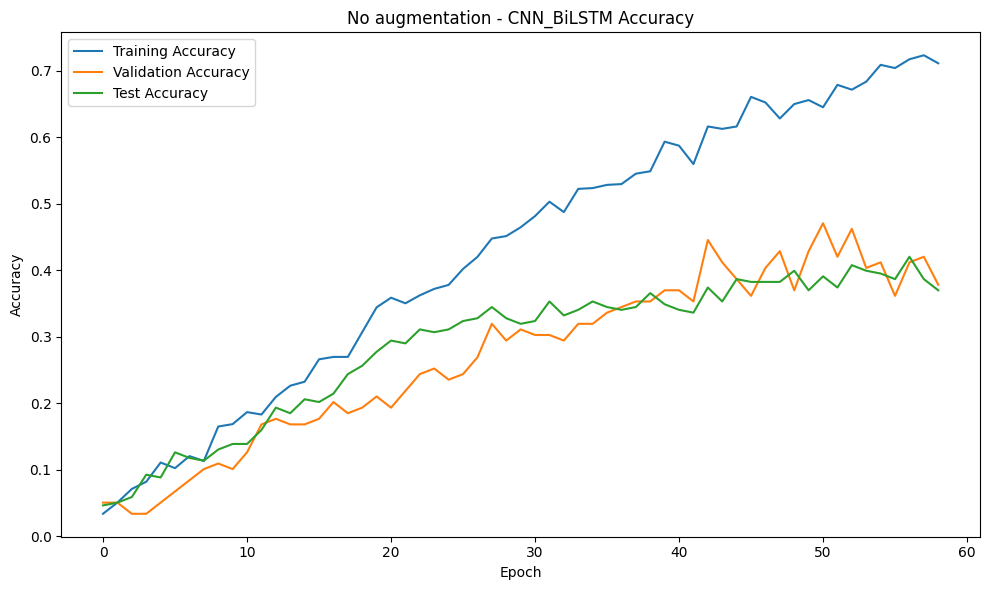

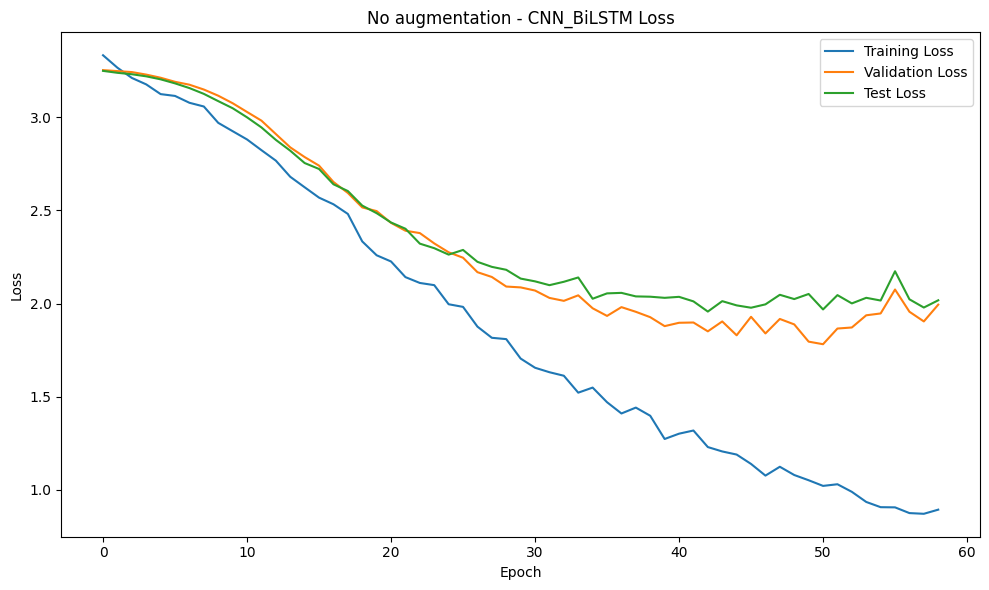

Finished CNN_BiLSTM
Test Accuracy: 0.3907563025210084
Macro F1: 0.39335187535936683

Setup: No augmentation
Training model: CNN_BiLSTM_NoDropout


Model: "CNN_BiLSTM_NoDropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 64)        │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,002 (308.60 KB)

 Trainable params: 78,874 (308.10 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0426 - loss: 3.2622 - test_loss: 3.2414 - test_accuracy: 0.0546
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.0650 - loss: 3.2301 - val_accuracy: 0.0336 - val_loss: 3.2301 - test_loss: 3.2414 - test_accuracy: 0.0546
Epoch 2/100
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1658 - loss: 3.0580 - test_loss: 3.2093 - test_accuracy: 0.0840
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1625 - loss: 3.0518 - val_accuracy: 0.0672 - val_loss: 3.2041 - test_loss: 3.2093 - test_accuracy: 0.0840
Epoch 3/100
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2242 - loss: 2.9143 - test_loss: 3.1624 - test_accuracy: 0.1092
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2154 - loss: 2.9024 - val_accuracy: 0.0924 - val_loss: 3.1659 - test_loss: 3.1624 - test_accuracy: 0.1092
Epoch 4/100
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2635 - loss: 2.7528 - test_loss: 3.0914 - test_accuracy: 0.1303


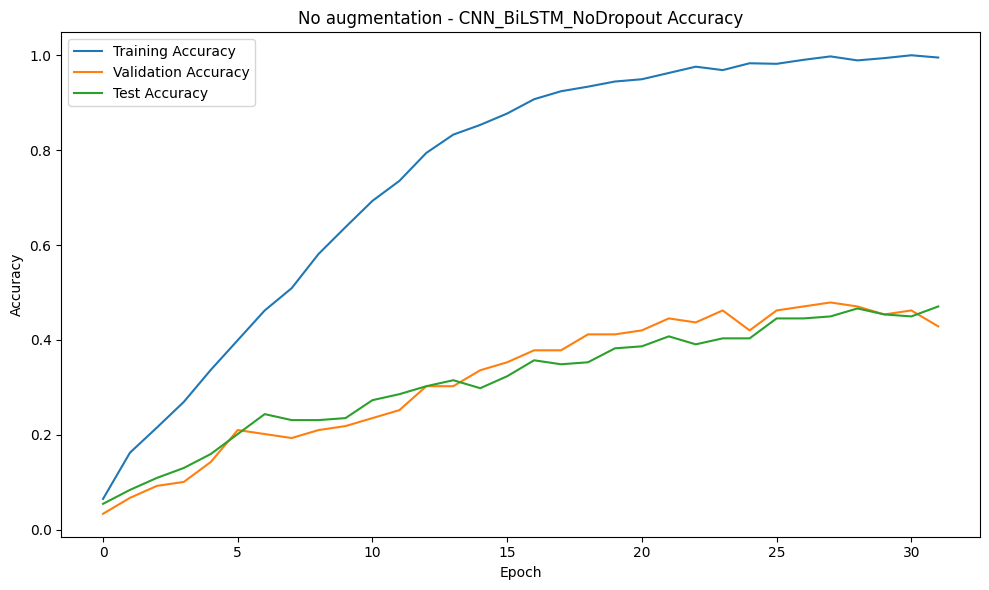

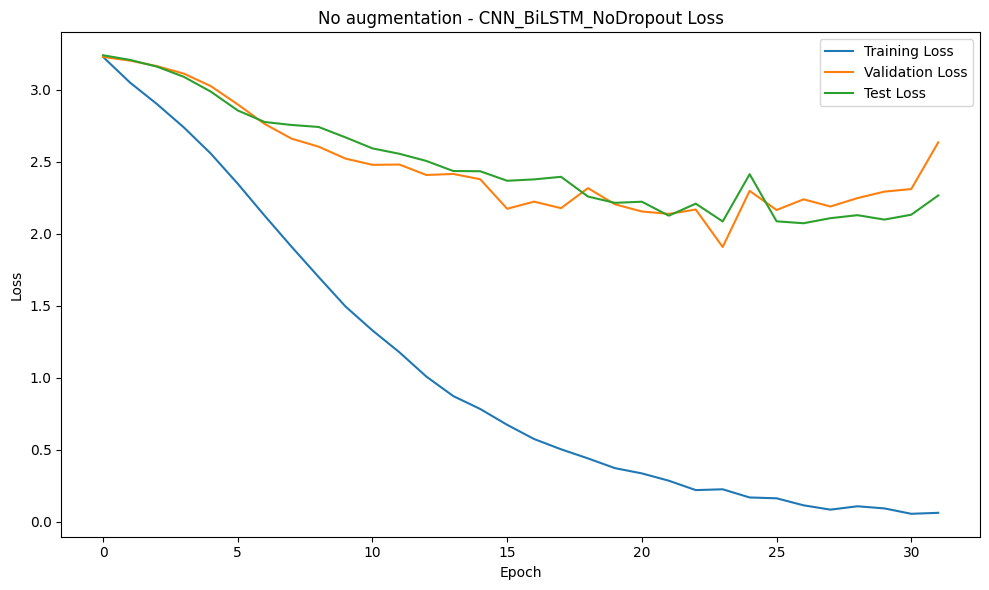

Finished CNN_BiLSTM_NoDropout
Test Accuracy: 0.40336134453781514
Macro F1: 0.40266978962579364
Final results for setup: No augmentation


,setup,model,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,best_val_accuracy,best_val_loss,epochs_trained,training_time_seconds,saved_model_path
0,No augmentation,CNN1D,1.589780,0.500000,0.535405,0.497436,0.499589,0.502460,0.512605,1.490270,81,35.377034,/kaggle/working/Dataset/stage1_final_outputs/n...
4,No augmentation,CNN_BiLSTM_NoDropout,2.086449,0.403361,0.428770,0.401709,0.402670,0.405134,0.478992,1.908805,32,15.649364,/kaggle/working/Dataset/stage1_final_outputs/n...
3,No augmentation,CNN_BiLSTM,1.968202,0.390756,0.429165,0.387607,0.393352,0.397517,0.470588,1.781740,59,28.301404,/kaggle/working/Dataset/stage1_final_outputs/n...
2,No augmentation,BiLSTM,2.408230,0.302521,0.314816,0.299573,0.286924,0.290541,0.386555,2.145093,67,39.167814,/kaggle/working/Dataset/stage1_final_outputs/n...
1,No augmentation,LSTM,2.630770,0.226891,0.221551,0.224786,0.195094,0.197444,0.268908,2.471639,80,36.514084,/kaggle/working/Dataset/stage1_final_outputs/n...


In [10]:
# ============================================================
# 10. Train no-augmentation models
# ============================================================

noaug_results_df, noaug_models, noaug_histories, noaug_predictions = train_and_compare_models(
    setup_name="No augmentation",
    X_train=X_train_noaug,
    y_train=y_train_noaug,
    y_train_cat=y_train_noaug_cat,
    X_test=X_test_noaug,
    y_test=y_test_noaug,
    y_test_cat=y_test_noaug_cat,
    output_dir=NOAUG_DIR,
    epochs=100,
    batch_size=64,
    patience=8
)

noaug_results_df.to_csv(OUTPUT_DIR / "stage1_model_comparison_no_augmentation.csv", index=False)


Setup: After Augmentation
Training model: CNN1D


Model: "CNN1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 64)        │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,962 (156.10 KB)

 Trainable params: 39,578 (154.60 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1078 - loss: 3.1245 - test_loss: 2.8624 - test_accuracy: 0.2408
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.1527 - loss: 2.9479 - val_accuracy: 0.2262 - val_loss: 2.8811 - test_loss: 2.8624 - test_accuracy: 0.2408
Epoch 2/100
103/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2381 - loss: 2.5852 - test_loss: 2.3502 - test_accuracy: 0.3567
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2560 - loss: 2.5023 - val_accuracy: 0.3234 - val_loss: 2.3764 - test_loss: 2.3502 - test_accuracy: 0.3567
Epoch 3/100
113/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2907 - loss: 2.3015 - test_loss: 2.0229 - test_accuracy: 0.4296
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3076 - loss: 2.2470 - val_accuracy: 0.4000 - val_loss: 2.0475 - test_loss: 2.0229 - test_accuracy: 0.4296
Epoch 4/100
111/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3366 - loss: 2.1384 - test_loss: 1.8256 - test_accuracy

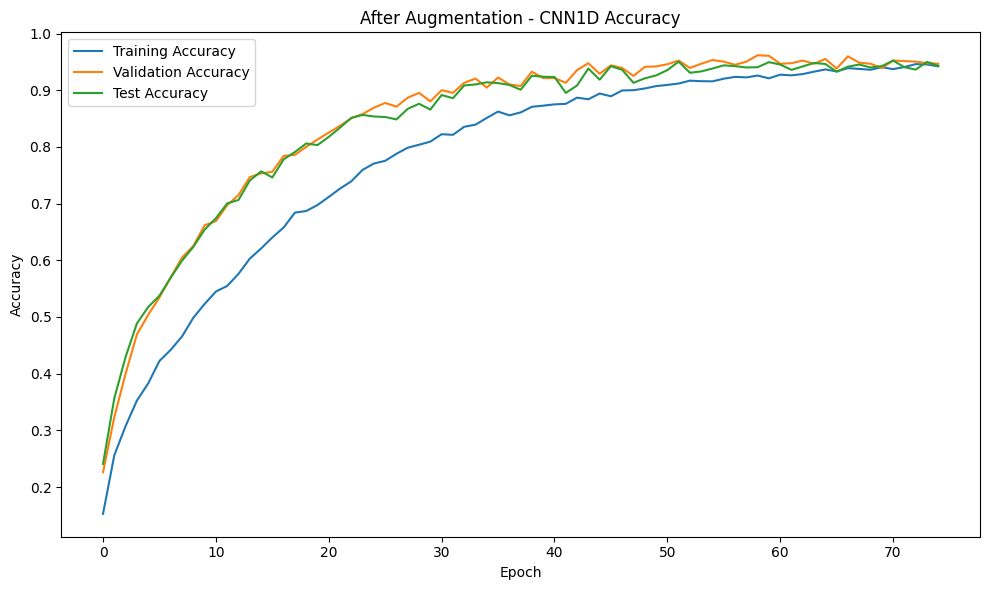

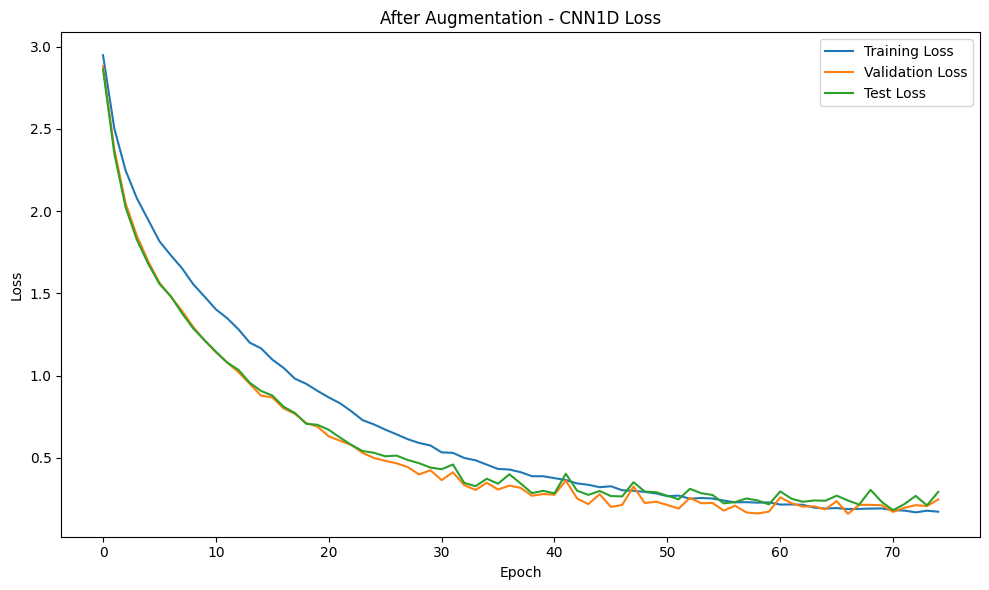

Finished CNN1D
Test Accuracy: 0.9415614773258532
Macro F1: 0.9414239634638174

Setup: After Augmentation
Training model: LSTM


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,442 (142.35 KB)

 Trainable params: 36,442 (142.35 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0401 - loss: 3.2629 - test_loss: 3.2231 - test_accuracy: 0.0767
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.0442 - loss: 3.2544 - val_accuracy: 0.0720 - val_loss: 3.2260 - test_loss: 3.2231 - test_accuracy: 0.0767
Epoch 2/100
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0588 - loss: 3.2192 - test_loss: 3.0769 - test_accuracy: 0.1061
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.0663 - loss: 3.1939 - val_accuracy: 0.1056 - val_loss: 3.0751 - test_loss: 3.0769 - test_accuracy: 0.1061
Epoch 3/100
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0945 - loss: 3.0866 - test_loss: 2.9113 - test_accuracy: 0.1253
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.0890 - loss: 3.0515 - val_accuracy: 0.1187 - val_loss: 2.9088 - test_loss: 2.9113 - test_accuracy: 0.1253
Epoch 4/100
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1010 - loss: 2.9511 - test_loss: 2.7682 - test_acc

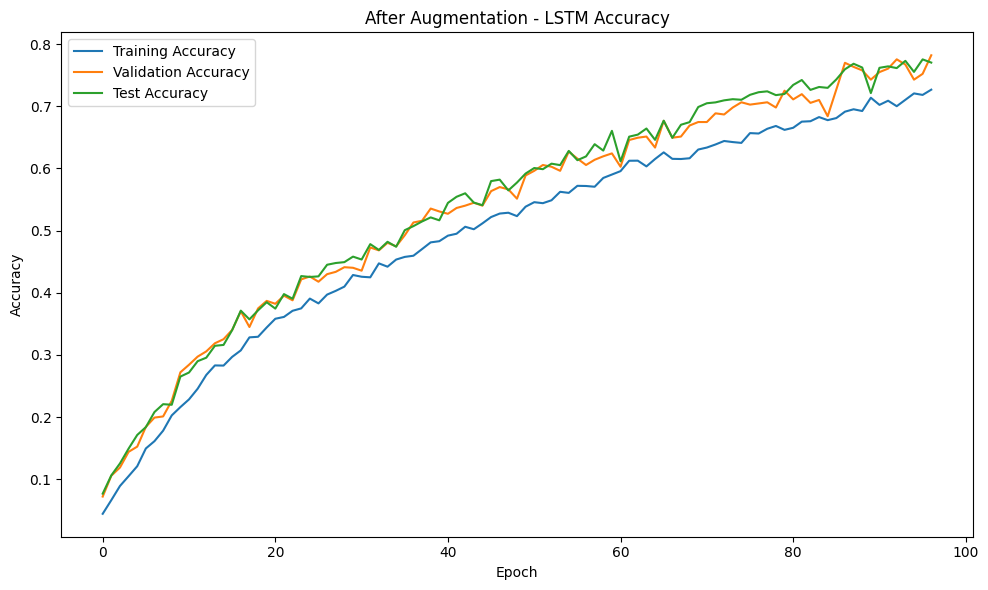

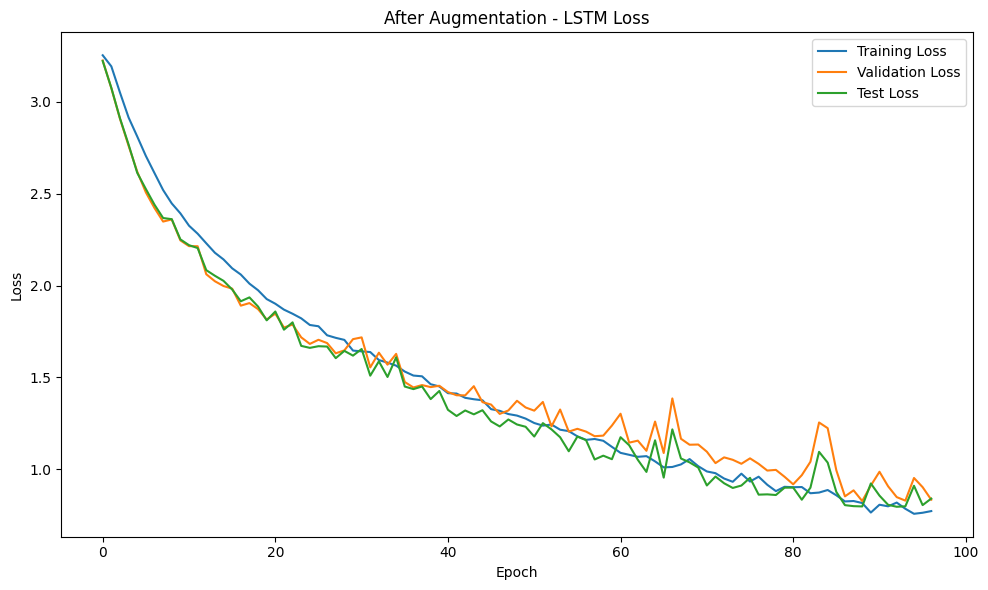

Finished LSTM
Test Accuracy: 0.7625058438522674
Macro F1: 0.7594907989653259

Setup: After Augmentation
Training model: BiLSTM


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,514 (341.85 KB)

 Trainable params: 87,514 (341.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0520 - loss: 3.2511 - test_loss: 3.1227 - test_accuracy: 0.1356
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.0641 - loss: 3.2267 - val_accuracy: 0.1224 - val_loss: 3.1396 - test_loss: 3.1227 - test_accuracy: 0.1356
Epoch 2/100
115/117 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1069 - loss: 3.1084 - test_loss: 2.8283 - test_accuracy: 0.2034
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.1212 - loss: 3.0503 - val_accuracy: 0.2000 - val_loss: 2.8860 - test_loss: 2.8283 - test_accuracy: 0.2034
Epoch 3/100
115/117 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1483 - loss: 2.8846 - test_loss: 2.5587 - test_accuracy: 0.2637
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.1670 - loss: 2.8178 - val_accuracy: 0.2355 - val_loss: 2.6212 - test_loss: 2.5587 - test_accuracy: 0.2637
Epoch 4/100
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2133 - loss: 2.6532 - test_loss: 2.3329 - test_acc

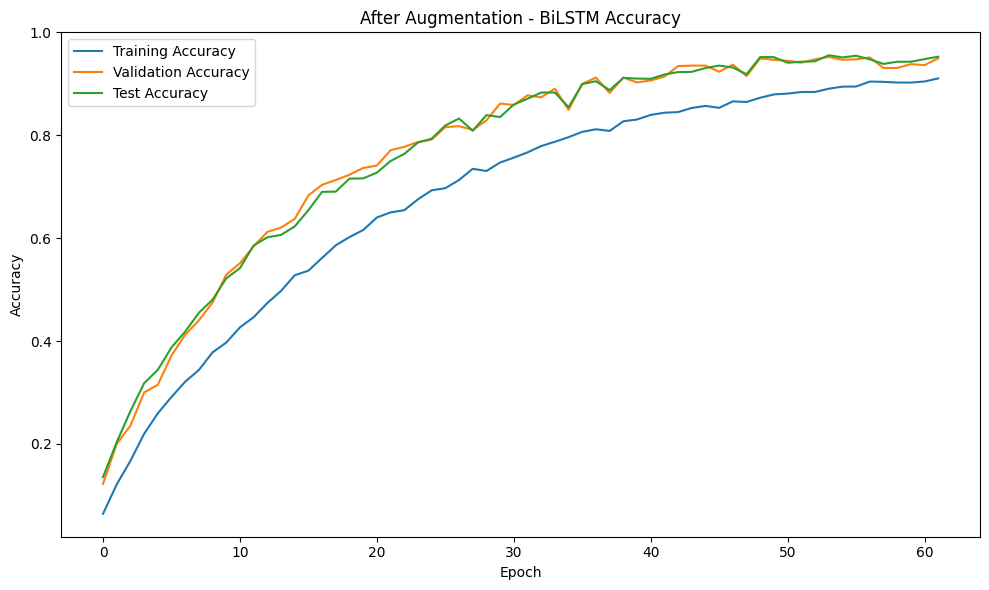

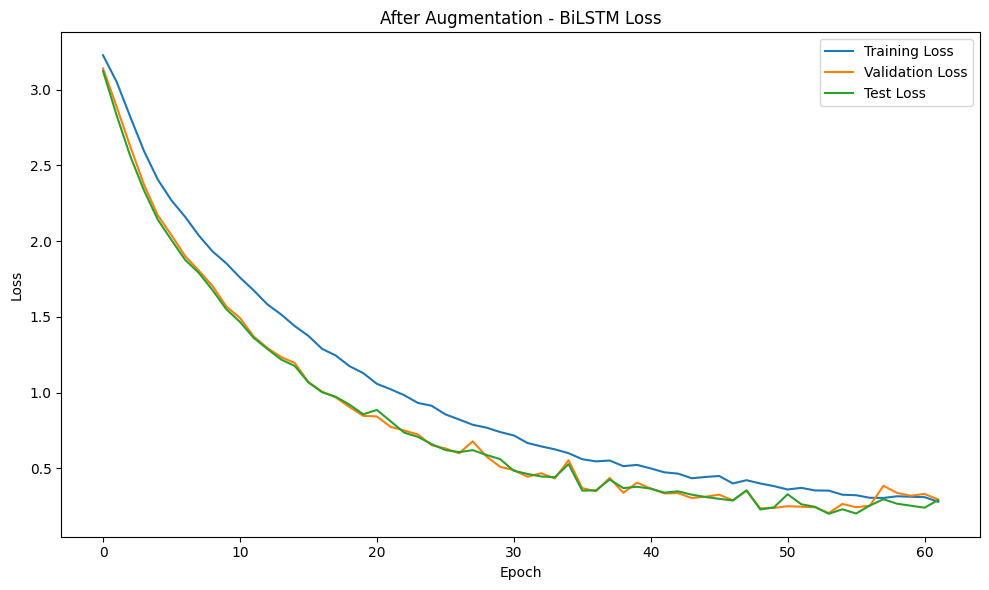

Finished BiLSTM
Test Accuracy: 0.9555867227676484
Macro F1: 0.9553866350260107

Setup: After Augmentation
Training model: CNN_BiLSTM


Model: "CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 64)        │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,002 (308.60 KB)

 Trainable params: 78,874 (308.10 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0447 - loss: 3.2933 - test_loss: 3.1097 - test_accuracy: 0.1459
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.0639 - loss: 3.2320 - val_accuracy: 0.1551 - val_loss: 3.1112 - test_loss: 3.1097 - test_accuracy: 0.1459
Epoch 2/100
115/117 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1234 - loss: 3.0401 - test_loss: 2.6636 - test_accuracy: 0.2370
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1438 - loss: 2.9625 - val_accuracy: 0.2299 - val_loss: 2.6660 - test_loss: 2.6636 - test_accuracy: 0.2370
Epoch 3/100
115/117 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2030 - loss: 2.6874 - test_loss: 2.2128 - test_accuracy: 0.3492
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2233 - loss: 2.5954 - val_accuracy: 0.3439 - val_loss: 2.2372 - test_loss: 2.2128 - test_accuracy: 0.3492
Epoch 4/100
115/117 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2700 - loss: 2.3961 - test_loss: 1.9129 - test_accura

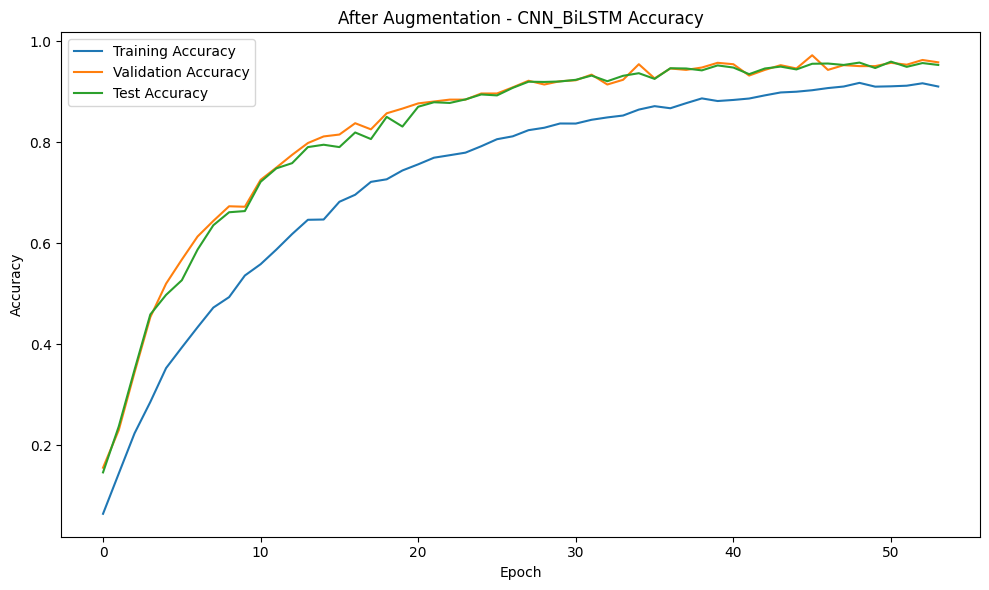

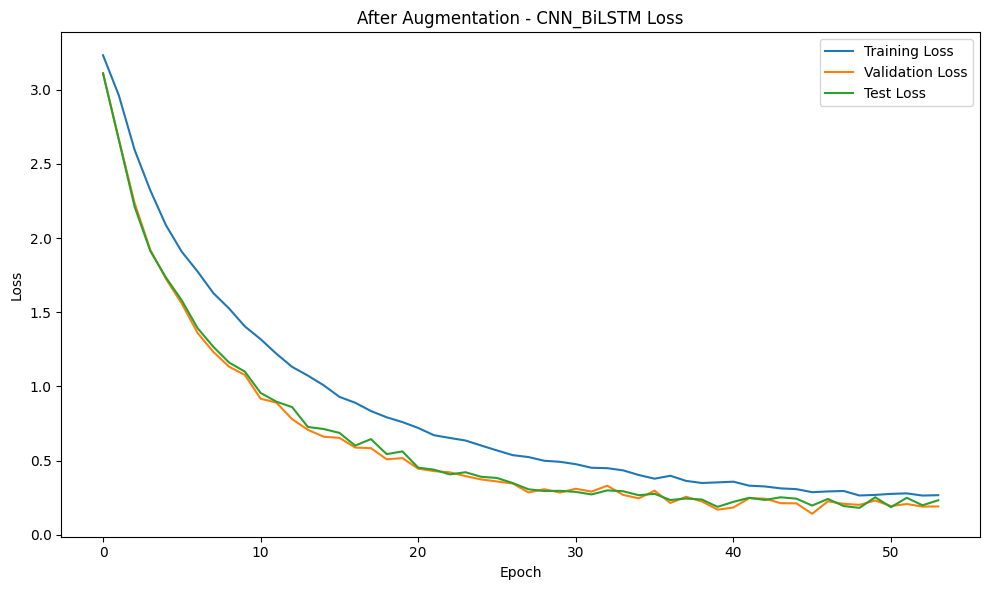

Finished CNN_BiLSTM
Test Accuracy: 0.9551192145862553
Macro F1: 0.9551698396314728

Setup: After Augmentation
Training model: CNN_BiLSTM_NoDropout


Model: "CNN_BiLSTM_NoDropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 64)        │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,002 (308.60 KB)

 Trainable params: 78,874 (308.10 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
115/117 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1204 - loss: 3.0935 - test_loss: 2.6634 - test_accuracy: 0.2239
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.1936 - loss: 2.8738 - val_accuracy: 0.2093 - val_loss: 2.6475 - test_loss: 2.6634 - test_accuracy: 0.2239
Epoch 2/100
115/117 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3769 - loss: 2.1587 - test_loss: 1.7960 - test_accuracy: 0.4689
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4326 - loss: 1.9663 - val_accuracy: 0.4383 - val_loss: 1.8218 - test_loss: 1.7960 - test_accuracy: 0.4689
Epoch 3/100
115/117 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5731 - loss: 1.5239 - test_loss: 1.2931 - test_accuracy: 0.6213
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6076 - loss: 1.3984 - val_accuracy: 0.6243 - val_loss: 1.3013 - test_loss: 1.2931 - test_accuracy: 0.6213
Epoch 4/100
115/117 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7000 - loss: 1.1042 - test_loss: 0.9462 - test_accura

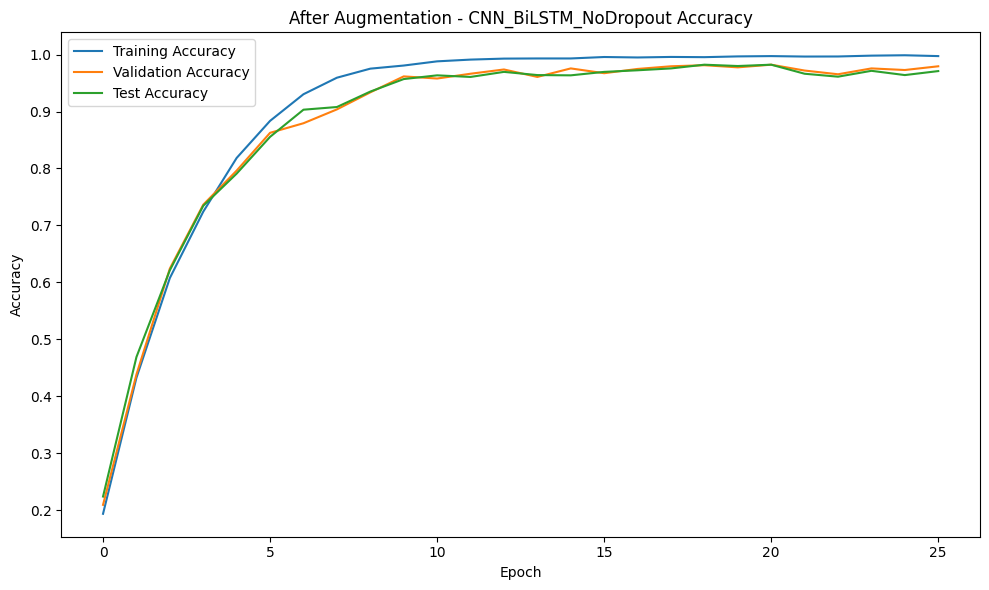

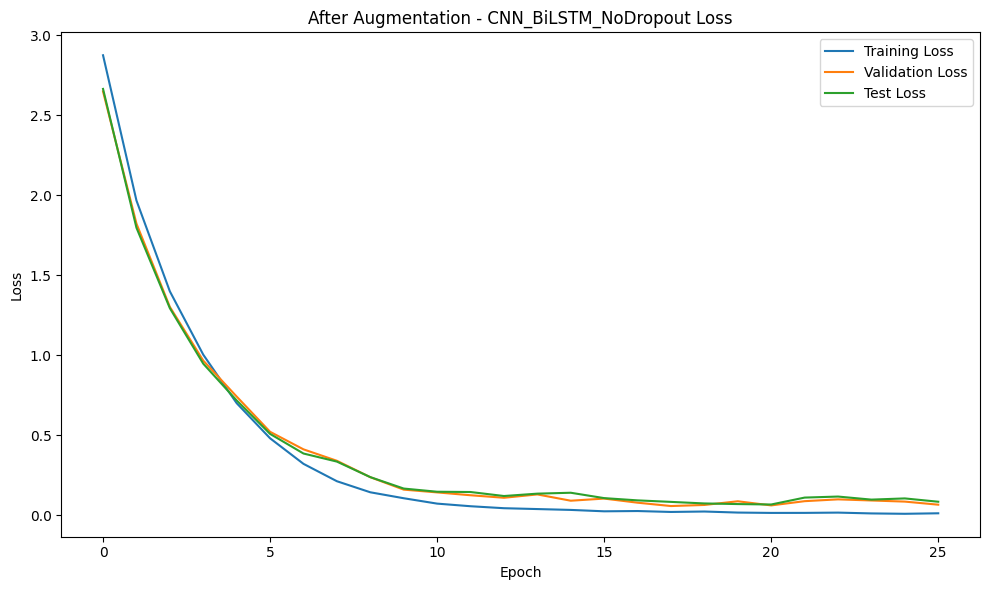

Finished CNN_BiLSTM_NoDropout
Test Accuracy: 0.9756895745675549
Macro F1: 0.9756710340487026
Final results for setup: After Augmentation


,setup,model,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,best_val_accuracy,best_val_loss,epochs_trained,training_time_seconds,saved_model_path
4,After Augmentation,CNN_BiLSTM_NoDropout,0.082658,0.975690,0.976371,0.975677,0.975671,0.975710,0.982243,0.056728,26,46.803517,/kaggle/working/Dataset/stage1_final_outputs/a...
2,After Augmentation,BiLSTM,0.201010,0.955587,0.956065,0.955640,0.955387,0.955398,0.952336,0.205541,62,186.870739,/kaggle/working/Dataset/stage1_final_outputs/a...
3,After Augmentation,CNN_BiLSTM,0.197626,0.955119,0.956161,0.955039,0.955170,0.955229,0.971963,0.142085,54,98.311653,/kaggle/working/Dataset/stage1_final_outputs/a...
0,After Augmentation,CNN1D,0.240085,0.941561,0.943286,0.941404,0.941424,0.941470,0.961682,0.159090,75,69.123589,/kaggle/working/Dataset/stage1_final_outputs/a...
1,After Augmentation,LSTM,0.797708,0.762506,0.769941,0.761391,0.759491,0.760654,0.782243,0.827111,97,188.017999,/kaggle/working/Dataset/stage1_final_outputs/a...


In [11]:
# ============================================================
# 11. Train paper-backed augmented within-dataset models
# ============================================================

aug_results_df, aug_models, aug_histories, aug_predictions = train_and_compare_models(
    setup_name="After Augmentation",
    X_train=X_train_aug,
    y_train=y_train_aug,
    y_train_cat=y_train_aug_cat,
    X_test=X_test_aug,
    y_test=y_test_aug,
    y_test_cat=y_test_aug_cat,
    output_dir=AUG_DIR,
    epochs=100,
    batch_size=64,
    patience=8
)

# This file name matches your earlier Stage 1 result convention
aug_results_df.to_csv(OUTPUT_DIR / "stage1_model_comparison_results.csv", index=False)
aug_results_df.to_csv(BASE_DIR / "stage1_model_comparison_results.csv", index=False)

,setup,model,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,best_val_accuracy,best_val_loss,epochs_trained,training_time_seconds,saved_model_path
5,After Augmentation,CNN_BiLSTM_NoDropout,0.082658,0.975690,0.976371,0.975677,0.975671,0.975710,0.982243,0.056728,26,46.803517,/kaggle/working/Dataset/stage1_final_outputs/a...
6,After Augmentation,BiLSTM,0.201010,0.955587,0.956065,0.955640,0.955387,0.955398,0.952336,0.205541,62,186.870739,/kaggle/working/Dataset/stage1_final_outputs/a...
7,After Augmentation,CNN_BiLSTM,0.197626,0.955119,0.956161,0.955039,0.955170,0.955229,0.971963,0.142085,54,98.311653,/kaggle/working/Dataset/stage1_final_outputs/a...
8,After Augmentation,CNN1D,0.240085,0.941561,0.943286,0.941404,0.941424,0.941470,0.961682,0.159090,75,69.123589,/kaggle/working/Dataset/stage1_final_outputs/a...
9,After Augmentation,LSTM,0.797708,0.762506,0.769941,0.761391,0.759491,0.760654,0.782243,0.827111,97,188.017999,/kaggle/working/Dataset/stage1_final_outputs/a...
0,No augmentation,CNN1D,1.589780,0.500000,0.535405,0.497436,0.499589,0.502460,0.512605,1.490270,81,35.377034,/kaggle/working/Dataset/stage1_final_outputs/n...
1,No augmentation,CNN_BiLSTM_NoDropout,2.086449,0.403361,0.428770,0.401709,0.402670,0.405134,0.478992,1.908805,32,15.649364,/kaggle/working/Dataset/stage1_final_outputs/n...
2,No augmentation,CNN_BiLSTM,1.968202,0.390756,0.429165,0.387607,0.393352,0.397517,0.470588,1.781740,59,28.301404,/kaggle/working/Dataset/stage1_final_outputs/n...
3,No augmentation,BiLSTM,2.408230,0.302521,0.314816,0.299573,0.286924,0.290541,0.386555,2.145093,67,39.167814,/kaggle/working/Dataset/stage1_final_outputs/n...
4,No augmentation,LSTM,2.630770,0.226891,0.221551,0.224786,0.195094,0.197444,0.268908,2.471639,80,36.514084,/kaggle/working/Dataset/stage1_final_outputs/n...


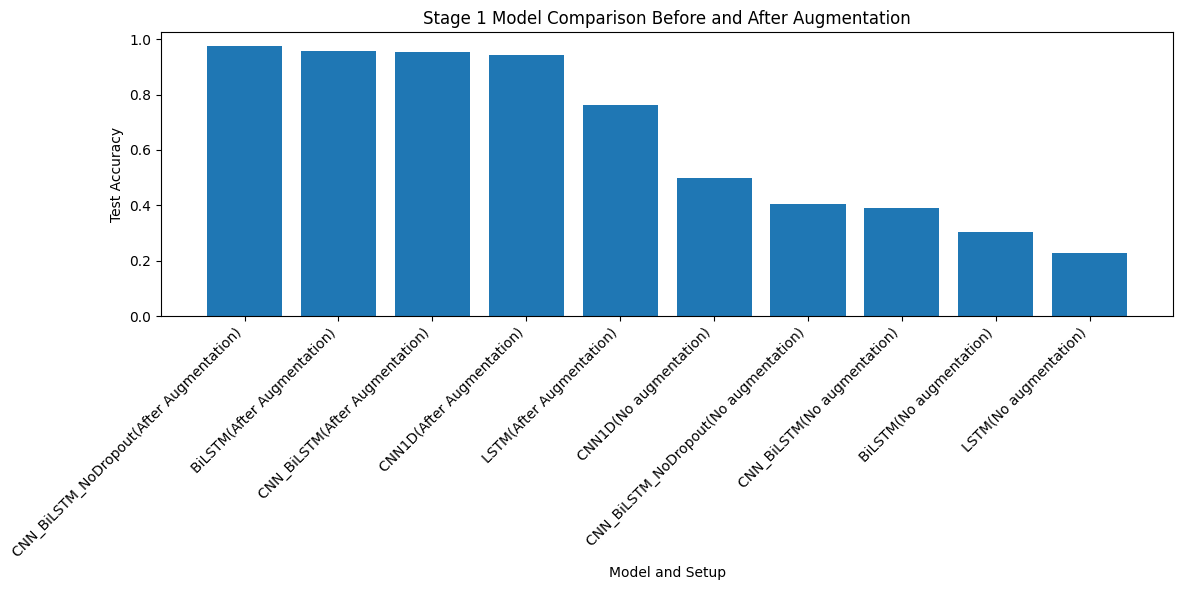

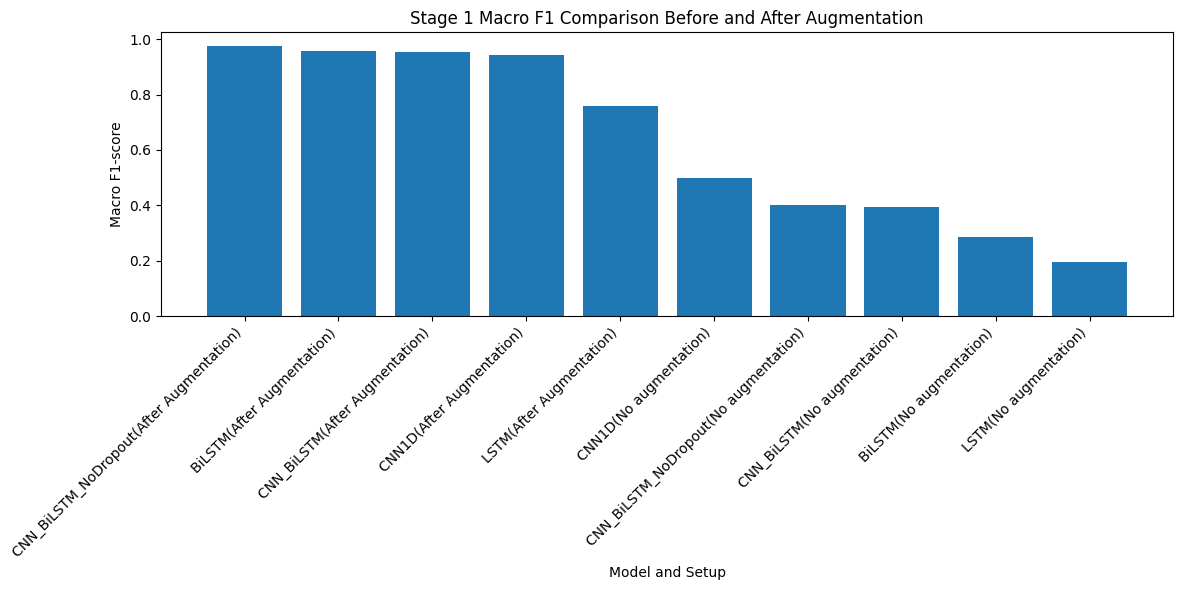

Saved combined comparison: /kaggle/working/Dataset/stage1_final_outputs/stage1_combined_model_comparison_before_after_augmentation.csv
Saved figures: /kaggle/working/Dataset/stage1_final_outputs/stage1_combined_accuracy_comparison.png /kaggle/working/Dataset/stage1_final_outputs/stage1_combined_macro_f1_comparison.png


In [12]:
# ============================================================
# 12. Combined comparison: before augmentation vs after augmentation
# ============================================================

combined_results_df = pd.concat([noaug_results_df, aug_results_df], ignore_index=True)
combined_results_df = combined_results_df.sort_values(by="test_accuracy", ascending=False)

combined_path = OUTPUT_DIR / "stage1_combined_model_comparison_before_after_augmentation.csv"
combined_results_df.to_csv(combined_path, index=False)

display(combined_results_df)

# Plot accuracy comparison
plot_df = combined_results_df.copy()
plot_df["model_setup"] = plot_df["model"] + "(" + plot_df["setup"] + ")"

plt.figure(figsize=(12, 6))
plt.bar(plot_df["model_setup"], plot_df["test_accuracy"])
plt.title("Stage 1 Model Comparison Before and After Augmentation")
plt.xlabel("Model and Setup")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
combined_acc_fig = OUTPUT_DIR / "stage1_combined_accuracy_comparison.png"
plt.savefig(combined_acc_fig, dpi=300, bbox_inches="tight")
plt.show()

# Plot macro F1 comparison
plt.figure(figsize=(12, 6))
plt.bar(plot_df["model_setup"], plot_df["macro_f1"])
plt.title("Stage 1 Macro F1 Comparison Before and After Augmentation")
plt.xlabel("Model and Setup")
plt.ylabel("Macro F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
combined_f1_fig = OUTPUT_DIR / "stage1_combined_macro_f1_comparison.png"
plt.savefig(combined_f1_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved combined comparison:", combined_path)
print("Saved figures:", combined_acc_fig, combined_f1_fig)

In [13]:
# ============================================================
# 13. Save final CNN-BiLSTM without dropout from augmented setup for Stage 2
# ============================================================

FINAL_MODEL_NAME = "CNN_BiLSTM_NoDropout"

final_model = aug_models[FINAL_MODEL_NAME]
final_history = aug_histories[FINAL_MODEL_NAME]
final_y_pred = aug_predictions[FINAL_MODEL_NAME]

# Evaluate final model again on augmented setup test split
test_loss, test_acc = final_model.evaluate(X_test_aug, y_test_aug_cat, verbose=0)

final_accuracy = accuracy_score(y_test_aug, final_y_pred)
final_macro_precision = precision_score(y_test_aug, final_y_pred, average="macro", zero_division=0)
final_macro_recall = recall_score(y_test_aug, final_y_pred, average="macro", zero_division=0)
final_macro_f1 = f1_score(y_test_aug, final_y_pred, average="macro", zero_division=0)
final_weighted_f1 = f1_score(y_test_aug, final_y_pred, average="weighted", zero_division=0)

# Save final model and scaler values using Stage 2 expected names
final_model.save(MODEL_PATH)
np.save(MEAN_PATH, mean_aug.astype(np.float32))
np.save(STD_PATH, std_aug.astype(np.float32))

# Also save in final output folder
final_model.save(FINAL_DIR / "stage1_final_cnn_bilstm_model.keras")
np.save(FINAL_DIR / "stage1_final_cnn_bilstm_mean.npy", mean_aug.astype(np.float32))
np.save(FINAL_DIR / "stage1_final_cnn_bilstm_std.npy", std_aug.astype(np.float32))

final_metrics_df = pd.DataFrame([{
    "final_model": FINAL_MODEL_NAME,
    "evaluation_setup": "Paper-backed augmented within-dataset random split",
    "test_loss": float(test_loss),
    "test_accuracy": float(final_accuracy),
    "macro_precision": float(final_macro_precision),
    "macro_recall": float(final_macro_recall),
    "macro_f1": float(final_macro_f1),
    "weighted_f1": float(final_weighted_f1),
    "input_shape": f"{TARGET_LEN} x {N_FEATURES}",
    "features": "8 EMG + 3 gyroscope + 3 acceleration",
    "orientation_used": "No",
    "saved_model_path": str(MODEL_PATH)
}])

final_metrics_path = FINAL_DIR / "stage1_final_cnn_bilstm_metrics.csv"
final_metrics_df.to_csv(final_metrics_path, index=False)
final_metrics_df.to_csv(BASE_DIR / "stage1_final_cnn_bilstm_metrics.csv", index=False)

display(final_metrics_df)

print("Saved final model for Stage 2:", MODEL_PATH)
print("Saved mean for Stage 2:", MEAN_PATH)
print("Saved std for Stage 2:", STD_PATH)
print("Saved label map:", LABEL_MAP_PATH)

,final_model,evaluation_setup,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,input_shape,features,orientation_used,saved_model_path
0,CNN_BiLSTM_NoDropout,Paper-backed augmented within-dataset random s...,0.082658,0.97569,0.976371,0.975677,0.975671,0.97571,100 x 14,8 EMG + 3 gyroscope + 3 acceleration,No,/kaggle/working/Dataset/stage1_augmented_split...


Saved final model for Stage 2: /kaggle/working/Dataset/stage1_augmented_split1_model.keras
Saved mean for Stage 2: /kaggle/working/Dataset/stage1_augmented_split1_mean.npy
Saved std for Stage 2: /kaggle/working/Dataset/stage1_augmented_split1_std.npy
Saved label map: /kaggle/working/Dataset/stage1_label_map.json


,precision,recall,f1-score,support
A,1.000000,1.000000,1.000000,81.00000
B,0.963415,0.975309,0.969325,81.00000
C,1.000000,1.000000,1.000000,81.00000
D,0.975000,0.962963,0.968944,81.00000
E,0.900000,1.000000,0.947368,81.00000
F,1.000000,0.975309,0.987500,81.00000
G,0.975309,0.951807,0.963415,83.00000
H,1.000000,1.000000,1.000000,86.00000
I,0.964286,0.975904,0.970060,83.00000
J,1.000000,1.000000,1.000000,81.00000


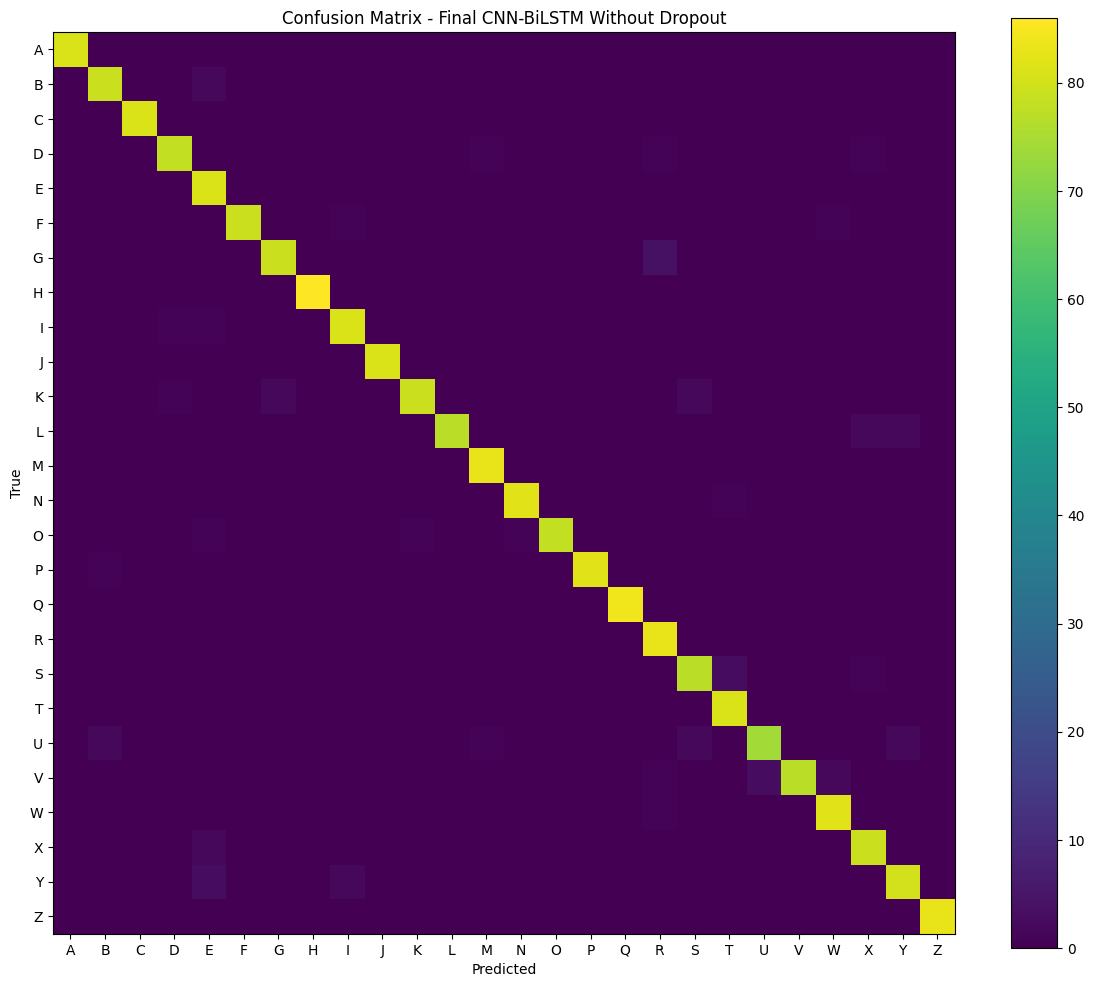

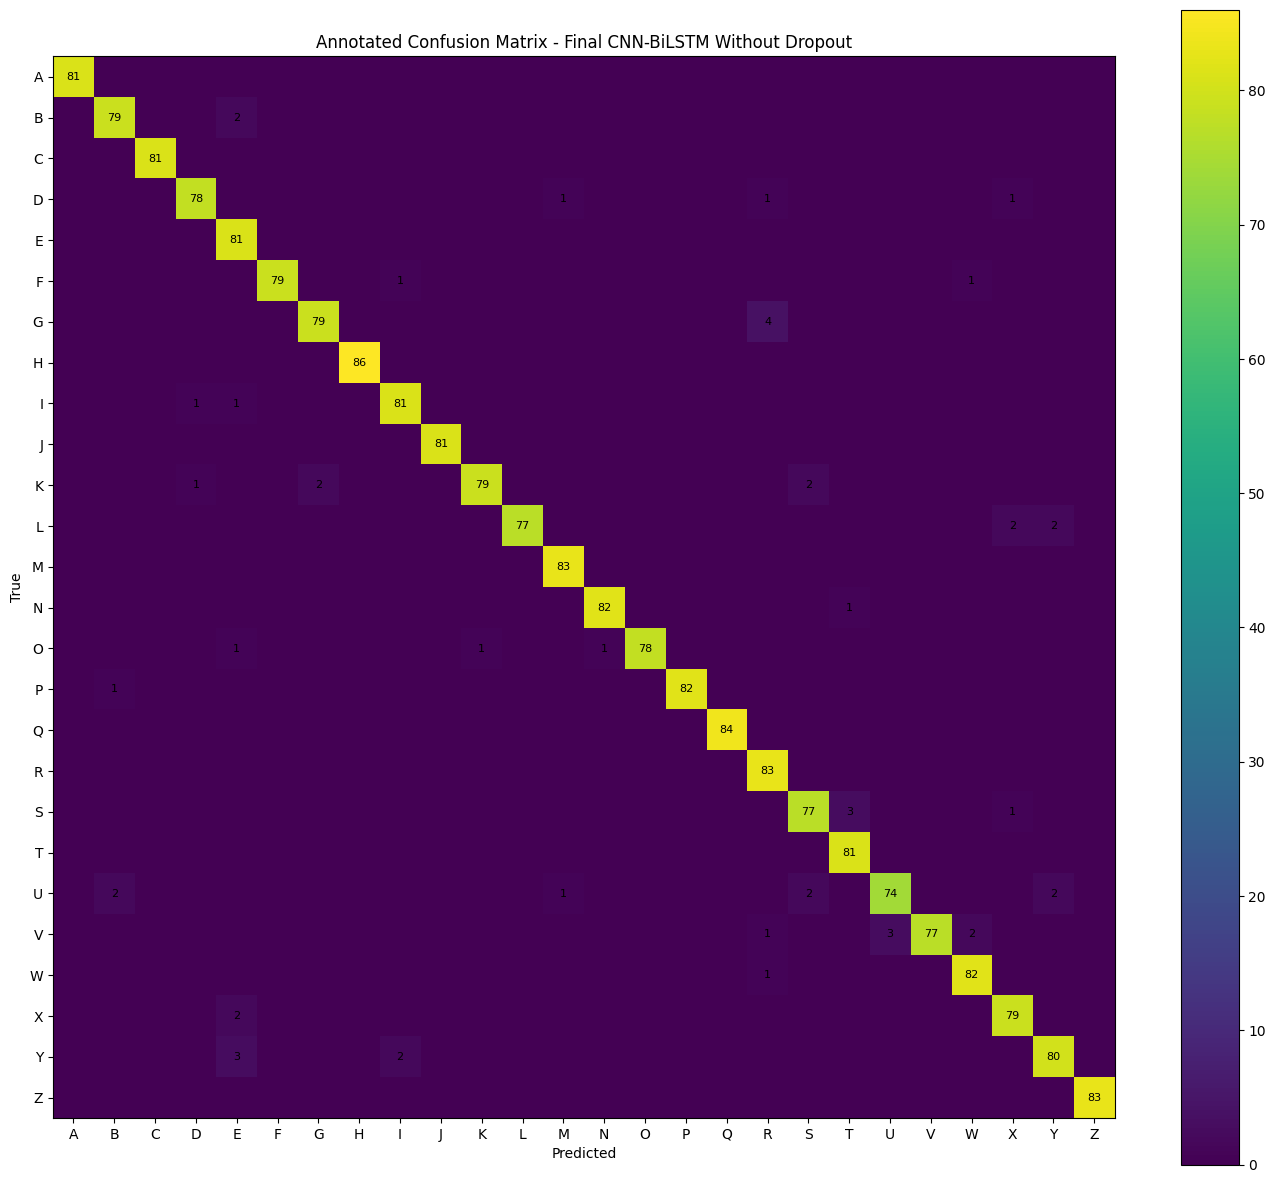

Saved final report: /kaggle/working/Dataset/stage1_final_outputs/final_cnn_bilstm/stage1_final_cnn_bilstm_classification_report.csv
Saved final confusion matrix CSV: /kaggle/working/Dataset/stage1_final_outputs/final_cnn_bilstm/stage1_final_cnn_bilstm_confusion_matrix.csv
Saved final confusion matrix image: /kaggle/working/Dataset/stage1_final_outputs/final_cnn_bilstm/stage1_final_cnn_bilstm_confusion_matrix.png
Saved annotated confusion matrix image: /kaggle/working/Dataset/stage1_final_outputs/final_cnn_bilstm/stage1_final_cnn_bilstm_confusion_matrix_annotated.png


In [14]:
# ============================================================
# 14. Final CNN-BiLSTM without dropout classification report and confusion matrix
# ============================================================

final_report_dict = classification_report(
    y_test_aug,
    final_y_pred,
    labels=list(range(N_CLASSES)),
    target_names=[inv_label_map[i] for i in range(N_CLASSES)],
    zero_division=0,
    output_dict=True
)

final_report_df = pd.DataFrame(final_report_dict).transpose()
final_report_path = FINAL_DIR / "stage1_final_cnn_bilstm_classification_report.csv"
final_report_df.to_csv(final_report_path)
final_report_df.to_csv(BASE_DIR / "stage1_final_cnn_bilstm_classification_report.csv")

display(final_report_df)

final_cm = confusion_matrix(y_test_aug, final_y_pred, labels=list(range(N_CLASSES)))
final_cm_df = pd.DataFrame(
    final_cm,
    index=[inv_label_map[i] for i in range(N_CLASSES)],
    columns=[inv_label_map[i] for i in range(N_CLASSES)]
)

final_cm_path = FINAL_DIR / "stage1_final_cnn_bilstm_confusion_matrix.csv"
final_cm_df.to_csv(final_cm_path)
final_cm_df.to_csv(BASE_DIR / "stage1_final_cnn_bilstm_confusion_matrix.csv")

plt.figure(figsize=(12, 10))
plt.imshow(final_cm)
plt.title("Confusion Matrix - Final CNN-BiLSTM Without Dropout")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(N_CLASSES), [inv_label_map[i] for i in range(N_CLASSES)])
plt.yticks(range(N_CLASSES), [inv_label_map[i] for i in range(N_CLASSES)])
plt.colorbar()
plt.tight_layout()
final_cm_fig = FINAL_DIR / "stage1_final_cnn_bilstm_confusion_matrix.png"
plt.savefig(final_cm_fig, dpi=300, bbox_inches="tight")
plt.show()

# Save an annotated version too
plt.figure(figsize=(14, 12))
plt.imshow(final_cm)
plt.title("Annotated Confusion Matrix - Final CNN-BiLSTM Without Dropout")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(N_CLASSES), [inv_label_map[i] for i in range(N_CLASSES)])
plt.yticks(range(N_CLASSES), [inv_label_map[i] for i in range(N_CLASSES)])
plt.colorbar()

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        value = final_cm[i, j]
        if value > 0:
            plt.text(j, i, str(value), ha="center", va="center", fontsize=8)

plt.tight_layout()
final_cm_annotated_fig = FINAL_DIR / "stage1_final_cnn_bilstm_confusion_matrix_annotated.png"
plt.savefig(final_cm_annotated_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved final report:", final_report_path)
print("Saved final confusion matrix CSV:", final_cm_path)
print("Saved final confusion matrix image:", final_cm_fig)
print("Saved annotated confusion matrix image:", final_cm_annotated_fig)

,accuracy,loss,val_accuracy,val_loss,test_loss,test_accuracy
21,0.996525,0.013956,0.971963,0.087136,0.109533,0.966339
22,0.996659,0.015682,0.965421,0.098462,0.115988,0.961197
23,0.998129,0.010591,0.975701,0.091452,0.096851,0.971482
24,0.998797,0.008259,0.972897,0.084473,0.104337,0.964002
25,0.997327,0.011430,0.979439,0.065168,0.083629,0.971014


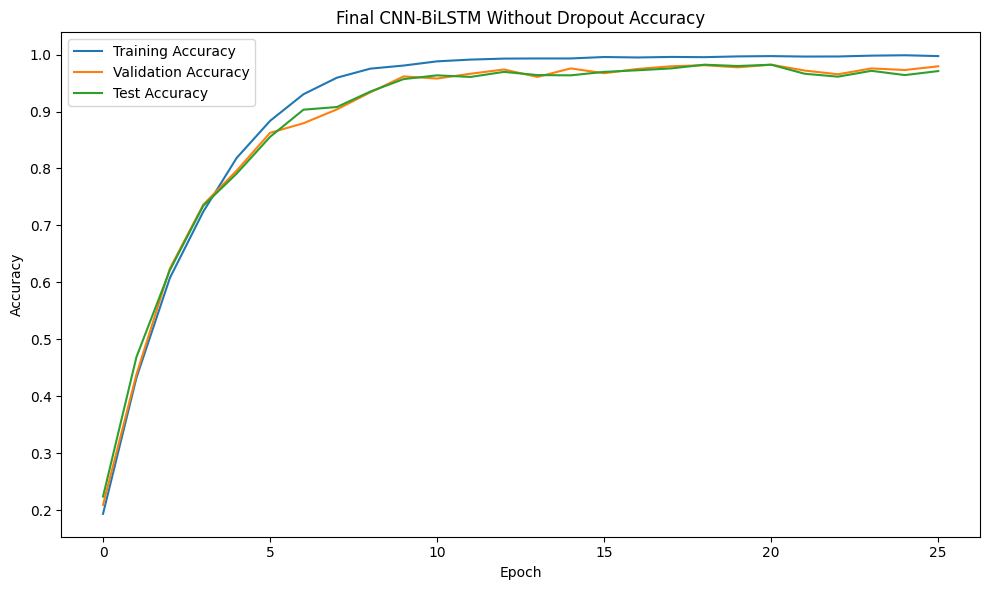

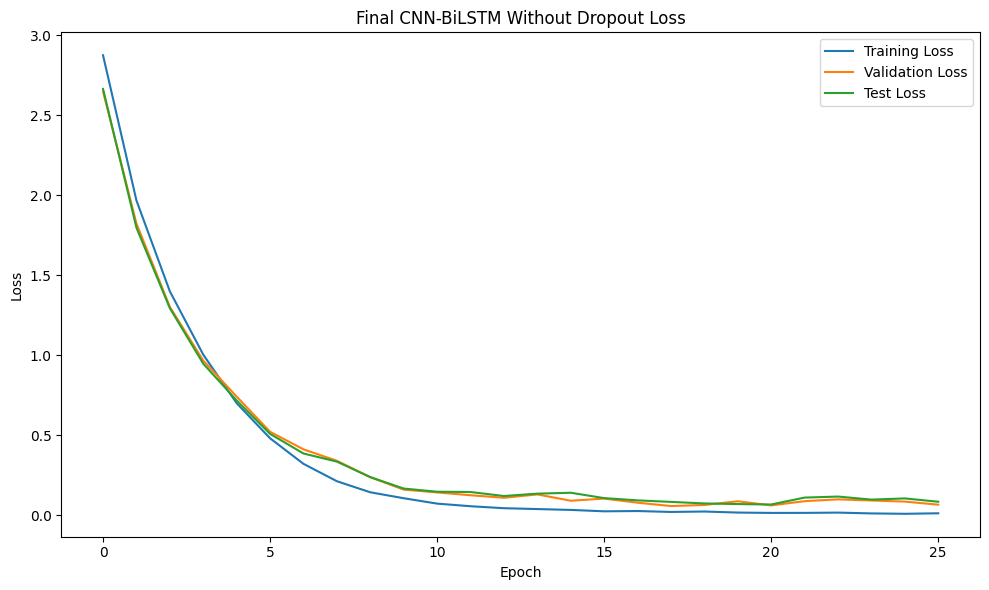

Saved final history: /kaggle/working/Dataset/stage1_final_outputs/final_cnn_bilstm/stage1_final_cnn_bilstm_training_history.csv
Saved accuracy curve: /kaggle/working/Dataset/stage1_final_outputs/final_cnn_bilstm/stage1_final_cnn_bilstm_accuracy_curve.png
Saved loss curve: /kaggle/working/Dataset/stage1_final_outputs/final_cnn_bilstm/stage1_final_cnn_bilstm_loss_curve.png


In [15]:
# ============================================================
# 15. Final CNN-BiLSTM without dropout training history and curves
# ============================================================

final_history_df = pd.DataFrame(final_history.history)
final_history_path = (
    FINAL_DIR /
    "stage1_final_cnn_bilstm_training_history.csv"
)
final_history_df.to_csv(final_history_path, index=False)
final_history_df.to_csv(
    BASE_DIR / "stage1_training_history.csv",
    index=False
)

display(final_history_df.tail())

epochs_axis = range(len(final_history.history["accuracy"]))

plt.figure(figsize=(10, 6))
plt.plot(
    epochs_axis,
    final_history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    epochs_axis,
    final_history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.plot(
    epochs_axis,
    final_history.history["test_accuracy"],
    label="Test Accuracy"
)
plt.title(
    "Final CNN-BiLSTM Without Dropout Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
final_acc_curve = (
    FINAL_DIR /
    "stage1_final_cnn_bilstm_accuracy_curve.png"
)
plt.savefig(
    final_acc_curve,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(
    epochs_axis,
    final_history.history["loss"],
    label="Training Loss"
)
plt.plot(
    epochs_axis,
    final_history.history["val_loss"],
    label="Validation Loss"
)
plt.plot(
    epochs_axis,
    final_history.history["test_loss"],
    label="Test Loss"
)
plt.title(
    "Final CNN-BiLSTM Without Dropout Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
final_loss_curve = (
    FINAL_DIR /
    "stage1_final_cnn_bilstm_loss_curve.png"
)
plt.savefig(
    final_loss_curve,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Also copy to BASE_DIR with the same simple names used before.
shutil.copy2(
    final_acc_curve,
    BASE_DIR / "stage1_accuracy_curve.png"
)
shutil.copy2(
    final_loss_curve,
    BASE_DIR / "stage1_loss_curve.png"
)
shutil.copy2(
    final_cm_fig,
    BASE_DIR /
    "stage1_final_cnn_bilstm_confusion_matrix.png"
)

print("Saved final history:", final_history_path)
print("Saved accuracy curve:", final_acc_curve)
print("Saved loss curve:", final_loss_curve)


In [16]:
# ============================================================
# 16. Misclassification analysis for Chapter 4
# ============================================================

misclassification_rows = []

for true_idx in range(N_CLASSES):
    for pred_idx in range(N_CLASSES):
        if true_idx == pred_idx:
            continue

        count = int(final_cm[true_idx, pred_idx])

        if count > 0:
            misclassification_rows.append({
                "true_letter": inv_label_map[true_idx],
                "predicted_letter": inv_label_map[pred_idx],
                "count": count
            })

misclassification_df = pd.DataFrame(misclassification_rows)

if len(misclassification_df) > 0:
    misclassification_df = misclassification_df.sort_values(by="count", ascending=False)
else:
    misclassification_df = pd.DataFrame(columns=["true_letter", "predicted_letter", "count"])

misclassification_path = FINAL_DIR / "stage1_final_cnn_bilstm_top_misclassifications.csv"
misclassification_df.to_csv(misclassification_path, index=False)

display(misclassification_df.head(20))

print("Saved misclassification analysis:", misclassification_path)

,true_letter,predicted_letter,count
6,G,R,4
30,Y,E,3
26,V,U,3
19,S,T,3
12,L,X,2
0,B,E,2
10,K,G,2
11,K,S,2
31,Y,I,2
23,U,S,2


Saved misclassification analysis: /kaggle/working/Dataset/stage1_final_outputs/final_cnn_bilstm/stage1_final_cnn_bilstm_top_misclassifications.csv


In [17]:
# # ============================================================
# # 17. Final output checklist
# # ============================================================

# important_files = [
#     MODEL_PATH,
#     MEAN_PATH,
#     STD_PATH,
#     LABEL_MAP_PATH,
#     BASE_DIR / "stage1_model_comparison_results.csv",
#     BASE_DIR / "stage1_final_cnn_bilstm_metrics.csv",
#     BASE_DIR / "stage1_final_cnn_bilstm_classification_report.csv",
#     BASE_DIR / "stage1_final_cnn_bilstm_confusion_matrix.csv",
#     BASE_DIR / "stage1_final_cnn_bilstm_confusion_matrix.png",
#     BASE_DIR / "stage1_training_history.csv",
#     BASE_DIR / "stage1_accuracy_curve.png",
#     BASE_DIR / "stage1_loss_curve.png",
#     OUTPUT_DIR / "stage1_combined_model_comparison_before_after_augmentation.csv",
#     OUTPUT_DIR / "stage1_combined_accuracy_comparison.png",
#     OUTPUT_DIR / "stage1_combined_macro_f1_comparison.png",
#     ANALYSIS_DIR / "class_distribution_before_after_augmentation.csv",
#     ANALYSIS_DIR / "class_distribution_before_augmentation.png",
#     ANALYSIS_DIR / "class_distribution_after_augmentation.png"
# ]

# print("Important Stage 1 output files:")
# for p in important_files:
#     print("FOUND" if Path(p).exists() else "MISSING", "-", p)

# # Zip outputs for download in Kaggle/local
# zip_path = BASE_DIR / "stage1_final_outputs_for_submission.zip"

# if zip_path.exists():
#     zip_path.unlink()

# shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", BASE_DIR)

# print("Created zip file:", zip_path)
# print("Stage 1 completed. Use the saved model, mean, std, and label map for Stage 2.")

In [18]:
from pathlib import Path
import os
import shutil

BASE_DIR = Path(BASE_DIR)

# Remove failed/partial zip files
for zip_file in BASE_DIR.glob("*.zip"):
    try:
        zip_file.unlink()
        print("Deleted partial zip:", zip_file)
    except Exception as e:
        print("Could not delete:", zip_file, e)

# Also check /kaggle/working for partial zip files
working_dir = Path("/kaggle/working")

for zip_file in working_dir.glob("*.zip"):
    try:
        zip_file.unlink()
        print("Deleted partial zip:", zip_file)
    except Exception as e:
        print("Could not delete:", zip_file, e)

print("Cleanup done.")

Cleanup done.


In [19]:
import shutil
from pathlib import Path

BASE_DIR = Path(BASE_DIR)

EXPORT_DIR = BASE_DIR / "stage1_final_submission_outputs"

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Important files for thesis and Stage 2
important_names = [
    # Stage 2 required files
    "stage1_augmented_split1_model.keras",
    "stage1_augmented_split1_mean.npy",
    "stage1_augmented_split1_std.npy",
    "stage1_label_map.json",

    # Model comparison and final result files
    "stage1_model_comparison_results.csv",
    "stage1_model_comparison_results_clean_split.csv",
    "stage1_combined_before_after_augmentation_comparison.csv",

    # Final CNN-BiLSTM result files
    "stage1_final_cnn_bilstm_metrics.csv",
    "stage1_final_cnn_bilstm_classification_report.csv",
    "stage1_final_cnn_bilstm_confusion_matrix.csv",
    "stage1_final_cnn_bilstm_confusion_matrix.png",

    # Training history and plots
    "stage1_final_cnn_bilstm_training_history.csv",
    "stage1_final_cnn_bilstm_accuracy_curve.png",
    "stage1_final_cnn_bilstm_loss_curve.png",

    # Dataset/augmentation analysis
    "stage1_dataset_summary.csv",
    "stage1_class_distribution_before_augmentation.csv",
    "stage1_class_distribution_after_augmentation.csv",
    "class_distribution_before_augmentation.png",
    "class_distribution_after_augmentation.png",
    "stage1_misclassification_analysis.csv"
]

copied = 0

for name in important_names:
    matches = list(BASE_DIR.rglob(name))

    if len(matches) == 0:
        print("Not found, skipping:", name)
        continue

    # Copy first match
    src = matches[0]
    dst = EXPORT_DIR / src.name

    try:
        shutil.copy2(src, dst)
        copied += 1
        print("Copied:", src.name)
    except Exception as e:
        print("Could not copy:", src, e)

print("\nTotal files copied:", copied)
print("Export folder:", EXPORT_DIR)

Copied: stage1_augmented_split1_model.keras
Copied: stage1_augmented_split1_mean.npy
Copied: stage1_augmented_split1_std.npy
Copied: stage1_label_map.json
Copied: stage1_model_comparison_results.csv
Not found, skipping: stage1_model_comparison_results_clean_split.csv
Not found, skipping: stage1_combined_before_after_augmentation_comparison.csv
Copied: stage1_final_cnn_bilstm_metrics.csv
Copied: stage1_final_cnn_bilstm_classification_report.csv
Copied: stage1_final_cnn_bilstm_confusion_matrix.csv
Copied: stage1_final_cnn_bilstm_confusion_matrix.png
Copied: stage1_final_cnn_bilstm_training_history.csv
Copied: stage1_final_cnn_bilstm_accuracy_curve.png
Copied: stage1_final_cnn_bilstm_loss_curve.png
Not found, skipping: stage1_dataset_summary.csv
Not found, skipping: stage1_class_distribution_before_augmentation.csv
Not found, skipping: stage1_class_distribution_after_augmentation.csv
Copied: class_distribution_before_augmentation.png
Copied: class_distribution_after_augmentation.png
Not f

In [20]:
import shutil
from pathlib import Path

EXPORT_DIR = Path(BASE_DIR) / "stage1_final_submission_outputs"
ZIP_PATH = Path("/kaggle/working/stage1_final_submission_outputs.zip")

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

shutil.make_archive(
    str(ZIP_PATH).replace(".zip", ""),
    "zip",
    EXPORT_DIR
)

print("Created final zip:")
print(ZIP_PATH)
print("Zip size MB:", ZIP_PATH.stat().st_size / (1024 * 1024))

Created final zip:
/kaggle/working/stage1_final_submission_outputs.zip
Zip size MB: 1.0537109375
